# Ultrasound Model Comparison: Trained Models vs Baselines

This notebook compares:

- **Three trained EchoCare-CLIP models** saved from `experiment_training_Mar26.ipynb`
- **OpenAI CLIP** zero-shot baseline
- **BiomedCLIP** zero-shot baseline

using two evaluations on a **held-out test split** of the labeled ultrasound datasets:

1. **Alignment score**: mean cosine similarity of matched image-caption pairs  
2. **Classification accuracy**: classify each image into a label using **prompted label text** and image-text similarity

This notebook is intentionally focused on **BUSI** and **BrEaST** because those datasets have label columns in the CSVs, making classification evaluation meaningful.


## Notebook roadmap

This notebook is organized into four blocks:

1. **Setup and dataset reconstruction**  
   Load dependencies, recreate the train/val/test split, and build evaluation datasets.

2. **Model loading and zero-shot evaluation**  
   Load OpenAI CLIP, BiomedCLIP, and trained models. Evaluate paired alignment and prompt-based zero-shot classification.

3. **Held-out supervised evaluation**  
   Extract frozen embeddings, run per-organ linear probes, and compare against few-shot adaptation on the held-out test split.

4. **Extra diagnostic tests**  
   Add retrieval metrics, bootstrap confidence intervals, and confusion-matrix diagnostics for the best probe results.

This version assumes the same Kaggle file layout and input format used earlier in the notebook.

In [1]:
# Install dependencies (run once)
!pip install -q monai transformers open_clip_torch einops pandas pillow matplotlib scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 34.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00


In [2]:
import os
import hashlib
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from transformers import (
    CLIPModel,
    CLIPProcessor,
    AutoModel,
    AutoTokenizer,
)
from monai.networks.nets.swin_unetr import SwinTransformer

from open_clip import create_model_from_pretrained, get_tokenizer

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

2026-04-25 01:05:59.411531: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777079159.881682      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777079160.008660      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777079161.082136      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777079161.082181      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777079161.082186      55 computation_placer.cc:177] computation placer alr

Using device: cuda


In [22]:

config = {
    # ------------------------------------------------------------------
    # Data loading / splitting: match experiment_Mar21.ipynb
    # ------------------------------------------------------------------
    "prepared_data_root": "/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data",

    # ------------------------------------------------------------------
    # Saved models
    # ------------------------------------------------------------------
    # "saved_model_dir": "/kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/1/saved_models_Mar25",
    # "trained_models": {
    #     "MLP heads only": "echocare_clip_mlp_heads_only.pt",
    #     "MLP + image encoder": "echocare_clip_mlp_and_image_encoder.pt",
    #     "MLP + text encoder": "echocare_clip_mlp_and_text_encoder.pt",
    # },
    "saved_model_dir": "/kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/4/EchoCare-CLIP-BERT-Apr24",
    "trained_models": {
        # "MLP heads only": "echocare_clip_mlp_heads_only.pt",
        # "MLP + image encoder": "echocare_clip_mlp_and_image_encoder.pt",
        # "MLP + text encoder": "echocare_clip_mlp_and_text_encoder.pt",
        # "MLP + image + text encoder": "echocare_clip_mlp_image_and_text_encoder.pt",
        "MLP heads only (BERT)": "echocare_bert_mlp_heads_only.pt",
        "MLP + image encoder (BERT)": "echocare_bert_mlp_and_image_encoder.pt",
        "MLP + text encoder (BERT)": "echocare_bert_mlp_and_text_encoder.pt",
        "MLP + image + text encoder (BERT)": "echocare_bert_mlp_image_and_text_encoder.pt",
    },

    # ------------------------------------------------------------------
    # Model settings (must match experiment_training_Mar26.ipynb)
    # ------------------------------------------------------------------
    "feature_size": 128,
    "in_channels": 3,
    "image_size": 256,
    "projection_dim": 256,
    # Trained BERT-text models: this must match the text encoder used during training.
    "text_model_name": "emilyalsentzer/Bio_ClinicalBERT",
    "max_seq_len": 128,

    # Backward-compatible alias used by a few older helper names.
    "clip_model_name": "emilyalsentzer/Bio_ClinicalBERT",
    'img_mean': [0.190874, 0.192657, 0.196386],
    'img_std' : [0.200044, 0.20141, 0.204307],

    # ------------------------------------------------------------------
    # Baseline model names
    # ------------------------------------------------------------------
    "openai_clip_model_name": "openai/clip-vit-base-patch32",
    "biomedclip_model_name": "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224",

    # ------------------------------------------------------------------
    # Evaluation split: EXACTLY like experiment_Mar21.ipynb
    # ------------------------------------------------------------------
    "test_size": 0.15,
    "val_size": 0.15,
    "random_seed": 42,
    "batch_size": 32,
    "num_workers": 0,

    "reference_train_csv": "/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/train_df.csv",
    "reference_val_csv": "/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/val_df.csv",
    "reference_test_csv": "/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/test_df.csv",
    "old_path_root": "/home/zhuoyangl/tryout/bmi702/data/data",
    "new_path_root": "/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data",
}
config


{'prepared_data_root': '/kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data',
 'saved_model_dir': '/kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/4/EchoCare-CLIP-BERT-Apr24',
 'trained_models': {'MLP heads only (BERT)': 'echocare_bert_mlp_heads_only.pt',
  'MLP + image encoder (BERT)': 'echocare_bert_mlp_and_image_encoder.pt',
  'MLP + text encoder (BERT)': 'echocare_bert_mlp_and_text_encoder.pt',
  'MLP + image + text encoder (BERT)': 'echocare_bert_mlp_image_and_text_encoder.pt'},
 'feature_size': 128,
 'in_channels': 3,
 'image_size': 256,
 'projection_dim': 256,
 'text_model_name': 'emilyalsentzer/Bio_ClinicalBERT',
 'max_seq_len': 128,
 'clip_model_name': 'emilyalsentzer/Bio_ClinicalBERT',
 'img_mean': [0.190874, 0.192657, 0.196386],
 'img_std': [0.200044, 0.20141, 0.204307],
 'openai_clip_model_name': 'openai/clip-vit-base-patch32',
 'biomedclip_model_name': 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224',
 'test_size'

## Load all prepared datasets and reproduce the same split logic as `experiment_Mar21.ipynb`

This section discovers every prepared dataset under `prepared_data_root`, auto-detects image-path and caption columns, resolves image paths, and then recreates the **same train/val/test split logic** used in `experiment_Mar21.ipynb`:

- `test_size = 0.15`
- `val_size = 0.15`
- `random_seed = 42`
- split stratified by **dataset source only**


In [4]:

def discover_datasets(root):
    """
    Walk the prepared_data root and return all (dataset_name, csv_path) pairs.
    A dataset folder is any directory that directly contains at least one .csv.
    If a folder has multiple CSVs, the largest one is used.
    """
    datasets = []
    for dirpath, dirnames, filenames in os.walk(root):
        csv_files = [f for f in filenames if f.lower().endswith(".csv")]
        if csv_files:
            dataset_name = os.path.basename(dirpath)
            csv_full = [os.path.join(dirpath, f) for f in csv_files]
            csv_full.sort(key=os.path.getsize, reverse=True)
            datasets.append((dataset_name, csv_full[0]))
    return sorted(datasets)


PATH_COL_CANDIDATES = [
    "file_name", "image_name", "path", "filename", "image_path", "filepath",
    "file", "image", "img_path", "img", "image_file"
]
CAPTION_COL_CANDIDATES = [
    "caption", "text_caption", "text_captions", "description", "text", "report",
    "finding", "findings", "annotation", "sentence"
]
LABEL_COL_CANDIDATES = ["label", "class", "condition", "diagnosis", "classification"]


def detect_column(df_columns, candidates):
    cols_lower = {c.lower(): c for c in df_columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None


def load_dataset_csv(csv_path, dataset_name):
    """
    Load a dataset CSV, auto-detecting path/caption columns.
    Returns unified columns: image_path, caption, dataset, label.
    Label is optional and may be NaN.
    """
    df = pd.read_csv(csv_path)

    path_col = detect_column(df.columns, PATH_COL_CANDIDATES)
    cap_col = detect_column(df.columns, CAPTION_COL_CANDIDATES)
    label_col = detect_column(df.columns, LABEL_COL_CANDIDATES)

    if path_col is None:
        raise ValueError(
            f"[{dataset_name}] Cannot detect image path column.\n"
            f"  Available: {list(df.columns)}\n"
            f"  Expected one of: {PATH_COL_CANDIDATES}"
        )
    if cap_col is None:
        raise ValueError(
            f"[{dataset_name}] Cannot detect caption column.\n"
            f"  Available: {list(df.columns)}\n"
            f"  Expected one of: {CAPTION_COL_CANDIDATES}"
        )

    out = pd.DataFrame({
        "image_path": df[path_col].astype(str),
        "caption": df[cap_col].astype(str),
        "dataset": dataset_name,
    })

    if label_col is not None:
        out["label"] = df[label_col].astype(str).str.strip().str.lower()
    else:
        out["label"] = pd.NA

    print(
        f"  [{dataset_name}] {len(out)} rows | "
        f"path_col={path_col!r} | caption_col={cap_col!r} | label_col={label_col!r}"
    )
    return out


def resolve_image_path(raw_path, csv_dir):
    """
    Try multiple strategies to locate an image file.
    Returns the first existing resolved path, or None.
    """
    basename = os.path.basename(str(raw_path))
    candidates = [
        str(raw_path),
        os.path.join(csv_dir, str(raw_path)),
        os.path.join(csv_dir, basename),
    ]
    # also try immediate subfolders of csv_dir
    try:
        for sub in os.listdir(csv_dir):
            subdir = os.path.join(csv_dir, sub)
            if os.path.isdir(subdir):
                candidates.append(os.path.join(subdir, basename))
    except Exception:
        pass

    seen = set()
    for p in candidates:
        if p in seen:
            continue
        seen.add(p)
        if os.path.exists(p):
            return os.path.abspath(p)
    return None


datasets_found = discover_datasets(config["prepared_data_root"])
print(f"Found {len(datasets_found)} dataset(s) under: {config['prepared_data_root']}\n")
for name, csv_path in datasets_found:
    print(f"  {name:40s}  ->  {csv_path}")

all_dfs = []
load_report = []

for dataset_name, csv_path in datasets_found:
    csv_dir = os.path.dirname(csv_path)
    try:
        df = load_dataset_csv(csv_path, dataset_name)
    except Exception as e:
        print(f"  [CSV ERROR] {dataset_name}: {e}")
        load_report.append((dataset_name, 0, 0, "CSV_ERROR"))
        continue

    resolved, n_ok, n_fail = [], 0, 0
    for raw_path in df["image_path"]:
        p = resolve_image_path(raw_path, csv_dir)
        resolved.append(p)
        if p is not None:
            n_ok += 1
        else:
            n_fail += 1

    df["resolved_path"] = resolved
    df_ok = df[df["resolved_path"].notna()].copy()
    df_ok["image_path"] = df_ok["resolved_path"]
    df_ok = df_ok.drop(columns=["resolved_path"])

    if len(df_ok) > 0:
        all_dfs.append(df_ok)

    status = "OK" if n_fail == 0 else f"{n_fail} missing"
    load_report.append((dataset_name, n_ok, n_fail, status))

print("\n" + "=" * 90)
print(f"{'Dataset':<42} {'Loaded':>8} {'Failed':>8}  Status")
print("=" * 90)
for name, n_ok, n_fail, status in load_report:
    ok_str = f"{n_ok:,}" if n_ok else "-"
    fail_str = f"{n_fail:,}" if n_fail else "-"
    print(f"{name:<42} {ok_str:>8} {fail_str:>8}  {status}")
print("=" * 90)
print(f"{'TOTAL':<42} {sum(r[1] for r in load_report):>8,} {sum(r[2] for r in load_report):>8,}")

if not all_dfs:
    raise RuntimeError(
        "No data loaded successfully! "
        f"Check that prepared_data_root exists: {config['prepared_data_root']}"
    )

full_df = pd.concat(all_dfs, ignore_index=True)[["image_path", "caption", "dataset", "label"]]
print(f"\nCombined dataset: {len(full_df):,} samples from {full_df['dataset'].nunique()} source(s)")
print(full_df["dataset"].value_counts())


Found 7 dataset(s) under: /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data

  AULI_resized_images                       ->  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/BUS-Lesion/Liver_ultrasound/AULI_resized_images/captions.csv
  BUS-Lesion                                ->  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/BUS-Lesion/bus_lesion_captions.csv
  BrEaST-Lesions_USG-images_and_masks       ->  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/BrEaST-Lesions_USG-images_and_masks/captions.csv
  Liver USData (with Chinese annotation)    ->  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/Liver USData (with Chinese annotation)/liver.csv
  Thyroid USData (with Chinese annotation)  ->  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/Thyroid USData (with Chin

In [26]:
from pathlib import Path
import os
import re
import pandas as pd

# ------------------------------------------------------------
# Utils
# ------------------------------------------------------------
def remap_path_to_kaggle(path):
    return str(path).replace(config["old_path_root"], config["new_path_root"])

def norm_rel_path(p):
    return str(p).replace("\\", "/").strip()

def normalize_filename(p):
    return Path(str(p)).name

def clean_label(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip().lower()
    if x in ["", "nan", "none", "unknown", "not available"]:
        return pd.NA
    return x

def infer_label_from_text(text):
    if pd.isna(text):
        return pd.NA

    s = str(text).lower()

    if re.search(r"\bmalignant\b|\bcarcinoma\b|\bcancer\b", s):
        return "malignant"
    if re.search(r"\bbenign\b|\bfibroadenoma\b", s):
        return "benign"
    if re.search(r"\bnormal\b|no clear space-occupying lesions|no obvious abnormal", s):
        return "normal"
    if re.search(r"\bcovid\b", s):
        return "covid"
    if re.search(r"\bpneumonia\b", s):
        return "pneumonia"

    return pd.NA

def standardize_label(raw):
    lab = clean_label(raw)
    if pd.isna(lab):
        return pd.NA

    s = str(lab)

    if "malignant" in s or "carcinoma" in s or "cancer" in s:
        return "malignant"
    if "benign" in s or "fibroadenoma" in s:
        return "benign"
    if "normal" in s:
        return "normal"
    if "covid" in s:
        return "covid"
    if "pneumonia" in s:
        return "pneumonia"

    return s

# ------------------------------------------------------------
# Load splits (train / val / test)
# ------------------------------------------------------------
def load_reference_split(csv_path):
    df = pd.read_csv(csv_path)
    df["image_path"] = df["image_path"].apply(remap_path_to_kaggle)

    if "caption" not in df.columns and "text_caption" in df.columns:
        df = df.rename(columns={"text_caption": "caption"})

    if "dataset" not in df.columns:
        df["dataset"] = "unknown"

    df["filename"] = df["image_path"].apply(normalize_filename)
    df["rel_tail_2"] = df["image_path"].apply(
        lambda p: "/".join(Path(str(p)).parts[-2:])
    )
    return df

train_df = load_reference_split(config["reference_train_csv"])
val_df   = load_reference_split(config["reference_val_csv"])
test_df  = load_reference_split(config["reference_test_csv"])

# ------------------------------------------------------------
# Build label lookup
# ------------------------------------------------------------
prepared_root = Path(config["new_path_root"])
caption_csvs = list(prepared_root.rglob("*.csv"))

lookup_rows = []

print("Found caption CSVs:")
for csv_file in caption_csvs:
    print(" ", csv_file)

for csv_file in caption_csvs:
    try:
        tmp = pd.read_csv(csv_file)
        tmp.columns = [c.strip() for c in tmp.columns]

        image_col = None
        for candidate in ["image_path", "image_name", "file_name", "filename"]:
            if candidate in tmp.columns:
                image_col = candidate
                break
        if image_col is None:
            continue

        label_col = None
        for col in tmp.columns:
            if col.lower() == "label":
                label_col = col
                break

        text_cols = [
            c for c in tmp.columns
            if c.lower() in ["caption", "text_caption", "annotation", "annotation_chinese"]
        ]

        tmp["raw_path"] = tmp[image_col].astype(str).apply(norm_rel_path)
        tmp["filename"] = tmp["raw_path"].apply(normalize_filename)
        tmp["rel_tail_2"] = tmp["raw_path"].apply(
            lambda p: "/".join(Path(str(p)).parts[-2:])
        )

        if label_col is not None:
            tmp["label"] = tmp[label_col].apply(standardize_label)
        else:
            tmp["label"] = pd.NA

        if len(text_cols) > 0:
            combined_text = tmp[text_cols].astype(str).agg(" ".join, axis=1)
            inferred = combined_text.apply(infer_label_from_text)
            tmp["label"] = tmp["label"].fillna(inferred)

        lookup_rows.append(tmp[["filename", "rel_tail_2", "label"]])

    except Exception as e:
        print(f"Failed to read {csv_file}: {e}")

label_lookup = pd.concat(lookup_rows, ignore_index=True)
label_lookup = label_lookup.dropna(subset=["label"]).drop_duplicates()

print("\nUnique labels found:")
print(label_lookup["label"].value_counts())

# ------------------------------------------------------------
# Attach labels (shared function)
# ------------------------------------------------------------
def attach_labels(df):
    df = df.copy()
    df["label"] = pd.NA

    filename_map = (
        label_lookup.drop_duplicates("filename")
        .set_index("filename")["label"]
        .to_dict()
    )
    df["label"] = df["filename"].map(filename_map)

    tail2_map = (
        label_lookup.drop_duplicates("rel_tail_2")
        .set_index("rel_tail_2")["label"]
        .to_dict()
    )

    missing = df["label"].isna()
    df.loc[missing, "label"] = df.loc[missing, "rel_tail_2"].map(tail2_map)

    if "caption" in df.columns:
        missing = df["label"].isna()
        df.loc[missing, "label"] = df.loc[missing, "caption"].apply(infer_label_from_text)

    df["path_exists"] = df["image_path"].apply(lambda p: os.path.exists(str(p)))
    df = df[df["path_exists"]].drop(columns=["path_exists"]).reset_index(drop=True)

    return df

train_df = attach_labels(train_df)
val_df   = attach_labels(val_df)
test_df  = attach_labels(test_df)

# ------------------------------------------------------------
# Build labeled subsets
# ------------------------------------------------------------
def get_labeled(df):
    return df[
        df["label"].notna() &
        (~df["label"].astype(str).str.lower().isin(["unknown", "nan", "none", ""]))
    ].reset_index(drop=True)

labeled_train_df = get_labeled(train_df)
labeled_val_df   = get_labeled(val_df)
labeled_test_df  = get_labeled(test_df)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("\nSplit sizes:")
print("train:", len(train_df), "| labeled:", len(labeled_train_df))
print("val  :", len(val_df),   "| labeled:", len(labeled_val_df))
print("test :", len(test_df),  "| labeled:", len(labeled_test_df))

print("\nTest label distribution:")
print(labeled_test_df["label"].value_counts())

print("\nLabeled test rows by dataset:")
print(labeled_test_df["dataset"].value_counts())

print("\nUnlabeled rows by dataset:")
print(test_df[test_df["label"].isna()]["dataset"].value_counts())

Found caption CSVs:
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/Thyroid USData (with Chinese annotation)/thyroid.csv
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/BUS-Lesion/bus_lesion_captions.csv
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/BUS-Lesion/bus_lesion_manifest.csv
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/BrEaST-Lesions_USG-images_and_masks/captions.csv
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/Liver USData (with Chinese annotation)/liver.csv
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/Thyroid/dataset_thyroid_resized_png/thyroid_template_captions_with_paths.csv
  /kaggle/input/datasets/yiyangzhangyoung/bmi702-preprocessed/prepared_data/prepared_data/BUS-Lesion/Liver_ultrasound/AULI_resized_images/capt

## Dataset / DataLoader for evaluation

For alignment-score evaluation we use the full held-out `test_df` from the same split logic as `experiment_Mar21.ipynb`. For classification, we restrict to `labeled_test_df` so unlabeled datasets do not break the prompt-based label evaluation.

In [6]:

class LabeledUltrasoundDataset(Dataset):
    def __init__(self, dataframe, split="test", cfg=config):
        self.df = dataframe.reset_index(drop=True)
        sz = cfg["image_size"]
        mean = cfg["img_mean"]
        std = cfg["img_std"]

        # deterministic transforms for evaluation
        self.transform = transforms.Compose([
            transforms.Resize(sz),
            transforms.CenterCrop(sz),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])

    def __len__(self):
        return len(self.df)

    def _safe_str(self, x, default=""):
        if pd.isna(x):
            return default
        return str(x)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = self._safe_str(row["image_path"])
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        caption = self._safe_str(row["caption"], default="")
        label = self._safe_str(row["label"], default="unknown") if "label" in row.index else "unknown"
        dataset = self._safe_str(row["dataset"], default="unknown")

        return image, caption, label, dataset, image_path

test_dataset = LabeledUltrasoundDataset(test_df, split="test")
test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=(device.type == "cuda"),
)

labeled_test_loader = None
if len(labeled_test_df) > 0:
    labeled_test_dataset = LabeledUltrasoundDataset(labeled_test_df, split="test")
    labeled_test_loader = DataLoader(
        labeled_test_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=(device.type == "cuda"),
    )

sample = test_dataset[0]
print("Sample image shape:", tuple(sample[0].shape))
print("Sample caption    :", sample[1][:120])
print("Sample label      :", sample[2])
print("Sample dataset    :", sample[3])


Sample image shape: (3, 256, 256)
Sample caption    : This lesion is parallel, has microlobulated margins and round shape, This lesion has hypoechoicwith absence of calcific 
Sample label      : benign
Sample dataset    : BUS-Lesion


## Trained model definitions (must match training notebook)

In [7]:
class EchoCareImageEncoder(nn.Module):
    def __init__(
        self,
        feature_size=128,
        in_channels=3,
        projection_dim=256,
        use_checkpoint=True,
        freeze_encoder=False,
    ):
        super().__init__()
        self.encoder = SwinTransformer(
            in_chans=in_channels,
            embed_dim=feature_size,
            window_size=[8, 8],
            patch_size=[2, 2],
            depths=[2, 2, 18, 2],
            num_heads=[4, 8, 16, 32],
            mlp_ratio=4.0,
            qkv_bias=True,
            use_checkpoint=use_checkpoint,
            spatial_dims=2,
            use_v2=True,
        )

        encoder_out_dim = feature_size * (2 ** 4)  # 2048

        self.projection = nn.Sequential(
            nn.Linear(encoder_out_dim, encoder_out_dim),
            nn.ReLU(),
            nn.Linear(encoder_out_dim, projection_dim),
        )

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

    def forward(self, x):
        feats = self.encoder(x)
        deep = feats[-1]
        emb = deep.mean(dim=(2, 3))
        emb = self.projection(emb)
        return F.normalize(emb, dim=-1)


class BERTTextEncoder(nn.Module):
    """
    Text tower for the BERT-based EchoCare-CLIP checkpoints.

    Important: this replaces the old CLIPTextEncoder used for the March CLIP-text
    checkpoints. The module attribute names are intentionally kept as
    self.text_encoder and self.projection so checkpoints load with the same
    state-dict prefixes: text_encoder.text_encoder.* and text_encoder.projection.*.
    """
    def __init__(
        self,
        text_model_name="bert-base-uncased",
        projection_dim=256,
        freeze_text_encoder=True,
    ):
        super().__init__()
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        text_out_dim = self.text_encoder.config.hidden_size

        if freeze_text_encoder:
            for p in self.text_encoder.parameters():
                p.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(text_out_dim, text_out_dim),
            nn.ReLU(),
            nn.Linear(text_out_dim, projection_dim),
        )

    def forward(self, input_ids, attention_mask=None):
        outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)

        # BERT usually has pooler_output; some AutoModel variants may not.
        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            text_emb = outputs.pooler_output
        else:
            text_emb = outputs.last_hidden_state[:, 0, :]  # CLS token fallback

        text_emb = self.projection(text_emb)
        return F.normalize(text_emb, dim=-1)


class EchoCare_CLIP(nn.Module):
    def __init__(self, image_encoder, text_encoder, init_temperature=0.07):
        super().__init__()
        self.image_encoder = image_encoder
        self.text_encoder = text_encoder
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(init_temperature)))

    def encode_image(self, images):
        return self.image_encoder(images)

    def encode_text(self, input_ids, attention_mask=None):
        return self.text_encoder(input_ids, attention_mask)

    def forward(self, images, input_ids, attention_mask=None):
        image_emb = self.encode_image(images)
        text_emb = self.encode_text(input_ids, attention_mask)
        temperature = self.log_temperature.exp()
        logits_per_image = (image_emb @ text_emb.T) / temperature
        logits_per_text = logits_per_image.T
        labels = torch.arange(image_emb.size(0), device=image_emb.device)
        loss_i2t = F.cross_entropy(logits_per_image, labels)
        loss_t2i = F.cross_entropy(logits_per_text, labels)
        loss = (loss_i2t + loss_t2i) / 2
        return loss, image_emb, text_emb


def build_trained_model():
    image_encoder = EchoCareImageEncoder(
        feature_size=config["feature_size"],
        in_channels=config["in_channels"],
        projection_dim=config["projection_dim"],
        freeze_encoder=False,
    )
    text_encoder = BERTTextEncoder(
        text_model_name=config.get("text_model_name", config["clip_model_name"]),
        projection_dim=config["projection_dim"],
        freeze_text_encoder=False,
    )
    model = EchoCare_CLIP(image_encoder, text_encoder, init_temperature=0.07)
    return model


# Tokenizer for the trained BERT-text models.
tokenizer = AutoTokenizer.from_pretrained(config.get("text_model_name", config["clip_model_name"]))


def tokenize_texts(texts, tokenizer, max_length=128, device="cpu"):
    encoded = tokenizer(
        texts,
        padding="max_length",
        max_length=max_length,
        truncation=True,
        return_tensors="pt",
    )
    return encoded["input_ids"].to(device), encoded["attention_mask"].to(device)


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

## Evaluation utilities

In [8]:
@torch.no_grad()
def compute_trained_model_alignment_score(model, dataloader, tokenizer, device):
    model.eval()
    all_img, all_txt = [], []

    for images, texts, labels, datasets, paths in tqdm(dataloader, desc="Trained model alignment", leave=False):
        images = images.to(device)
        ids, mask = tokenize_texts(list(texts), tokenizer, max_length=config["max_seq_len"], device=device)
        img_emb = model.encode_image(images)
        txt_emb = model.encode_text(ids, mask)
        all_img.append(img_emb.cpu())
        all_txt.append(txt_emb.cpu())

    img_embs = torch.cat(all_img, dim=0)
    txt_embs = torch.cat(all_txt, dim=0)

    paired_sim = (img_embs * txt_embs).sum(dim=1).mean().item()
    all_sim = img_embs @ txt_embs.T
    off_mask = ~torch.eye(img_embs.size(0), dtype=torch.bool)
    cross_sim = all_sim[off_mask].mean().item()
    return paired_sim, cross_sim


@torch.no_grad()
def compute_openai_clip_alignment_score_from_df(df, model, processor, device, batch_size=32):
    all_img, all_txt = [], []
    for start in tqdm(range(0, len(df), batch_size), desc="OpenAI CLIP baseline", leave=False):
        batch_df = df.iloc[start:start + batch_size]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        texts = batch_df["caption"].tolist()

        inputs = processor(
            text=texts,
            images=pil_images,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(device)

        outputs = model(**inputs)
        image_features = F.normalize(outputs.image_embeds, dim=-1)
        text_features = F.normalize(outputs.text_embeds, dim=-1)

        all_img.append(image_features.cpu())
        all_txt.append(text_features.cpu())

    img_embs = torch.cat(all_img, dim=0)
    txt_embs = torch.cat(all_txt, dim=0)

    paired_sim = (img_embs * txt_embs).sum(dim=1).mean().item()
    all_sim = img_embs @ txt_embs.T
    off_mask = ~torch.eye(img_embs.size(0), dtype=torch.bool)
    cross_sim = all_sim[off_mask].mean().item()
    return paired_sim, cross_sim


@torch.no_grad()
def compute_biomedclip_alignment_score_from_df(df, model, preprocess, tokenizer, device, batch_size=32):
    all_img, all_txt = [], []
    for start in tqdm(range(0, len(df), batch_size), desc="BiomedCLIP baseline", leave=False):
        batch_df = df.iloc[start:start + batch_size]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        images = torch.stack([preprocess(img) for img in pil_images]).to(device)
        texts = batch_df["caption"].tolist()
        text_tokens = tokenizer(texts, context_length=256).to(device)

        image_features = F.normalize(model.encode_image(images), dim=-1)
        text_features = F.normalize(model.encode_text(text_tokens), dim=-1)

        all_img.append(image_features.cpu())
        all_txt.append(text_features.cpu())

    img_embs = torch.cat(all_img, dim=0)
    txt_embs = torch.cat(all_txt, dim=0)

    paired_sim = (img_embs * txt_embs).sum(dim=1).mean().item()
    all_sim = img_embs @ txt_embs.T
    off_mask = ~torch.eye(img_embs.size(0), dtype=torch.bool)
    cross_sim = all_sim[off_mask].mean().item()
    return paired_sim, cross_sim


# Prompted-label classification is more reasonable than raw label strings.
# These models were trained on natural-language captions, not just class names.
def build_label_prompt(label):
    label = str(label).strip().lower()
    return f"An ultrasound image of breast with {label} findings."


@torch.no_grad()
def classify_with_trained_model(model, dataloader, label_prompts, tokenizer, device):
    model.eval()
    label_names = list(label_prompts.keys())
    prompt_texts = [label_prompts[l] for l in label_names]
    ids, mask = tokenize_texts(prompt_texts, tokenizer, max_length=config["max_seq_len"], device=device)
    text_embs = model.encode_text(ids, mask)  # (L, D)

    y_true, y_pred = [], []
    for images, texts, labels, datasets, paths in tqdm(dataloader, desc="Trained model classification", leave=False):
        images = images.to(device)
        img_embs = model.encode_image(images)  # (B, D)
        sims = img_embs @ text_embs.T          # (B, L)
        pred_idx = sims.argmax(dim=1).cpu().numpy()

        y_true.extend(list(labels))
        y_pred.extend([label_names[i] for i in pred_idx])

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred


@torch.no_grad()
def classify_with_openai_clip(df, label_prompts, model, processor, device, batch_size=32):
    model.eval()

    label_names = list(label_prompts.keys())
    label_texts = [label_prompts[k] for k in label_names]

    text_inputs = processor(
        text=label_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(device)

    text_out = model.get_text_features(
        input_ids=text_inputs["input_ids"],
        attention_mask=text_inputs["attention_mask"],
    )

    # Some transformers versions return a structured output instead of a tensor
    if hasattr(text_out, "pooler_output") and text_out.pooler_output is not None:
        text_out = text_out.pooler_output
    elif hasattr(text_out, "last_hidden_state"):
        text_out = text_out.last_hidden_state[:, 0, :]

    text_embs = F.normalize(text_out, dim=-1)

    y_true, y_pred = [], []

    for start in tqdm(range(0, len(df), batch_size), desc="OpenAI CLIP classification", leave=False):
        batch_df = df.iloc[start:start + batch_size]

        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        true_labels = batch_df["label"].tolist()

        img_inputs = processor(
            images=pil_images,
            return_tensors="pt",
        ).to(device)

        img_out = model.get_image_features(pixel_values=img_inputs["pixel_values"])

        if hasattr(img_out, "pooler_output") and img_out.pooler_output is not None:
            img_out = img_out.pooler_output
        elif hasattr(img_out, "last_hidden_state"):
            img_out = img_out.last_hidden_state[:, 0, :]

        img_embs = F.normalize(img_out, dim=-1)

        sims = img_embs @ text_embs.T
        pred_idx = sims.argmax(dim=1).cpu().tolist()
        pred_labels = [label_names[i] for i in pred_idx]

        y_true.extend(true_labels)
        y_pred.extend(pred_labels)

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred

@torch.no_grad()
def classify_with_biomedclip(df, label_prompts, model, preprocess, tokenizer, device, batch_size=32):
    label_names = list(label_prompts.keys())
    prompt_texts = [label_prompts[l] for l in label_names]
    text_tokens = tokenizer(prompt_texts, context_length=256).to(device)
    text_embs = F.normalize(model.encode_text(text_tokens), dim=-1)

    y_true, y_pred = [], []
    for start in tqdm(range(0, len(df), batch_size), desc="BiomedCLIP classification", leave=False):
        batch_df = df.iloc[start:start + batch_size]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        images = torch.stack([preprocess(img) for img in pil_images]).to(device)
        img_embs = F.normalize(model.encode_image(images), dim=-1)
        sims = img_embs @ text_embs.T
        pred_idx = sims.argmax(dim=1).cpu().numpy()

        y_true.extend(batch_df["label"].tolist())
        y_pred.extend([label_names[i] for i in pred_idx])

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred

## Load baseline models

In [9]:
print("Loading OpenAI CLIP baseline...")
openai_clip_model = CLIPModel.from_pretrained(config["openai_clip_model_name"]).to(device).eval()
openai_clip_processor = CLIPProcessor.from_pretrained(config["openai_clip_model_name"])

print("Loading BiomedCLIP baseline...")
biomedclip_model, biomedclip_preprocess = create_model_from_pretrained(config["biomedclip_model_name"])
biomedclip_tokenizer = get_tokenizer(config["biomedclip_model_name"])
biomedclip_model = biomedclip_model.to(device).eval()

print("Baselines loaded.")

Loading OpenAI CLIP baseline...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Baselines loaded.


## Load the three trained models

In [10]:
trained_models = {}

for model_name, filename in config["trained_models"].items():
    model_path = Path(config["saved_model_dir"]) / filename
    if not model_path.exists():
        raise FileNotFoundError(f"Missing trained model file: {model_path}")

    model = build_trained_model().to(device)
    state_dict = torch.load(model_path, map_location=device)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    model.eval()

    print(f"Loaded {model_name}")
    print(f"  file      : {model_path}")
    print(f"  missing   : {missing[:5]}")
    print(f"  unexpected: {unexpected[:5]}")

    trained_models[model_name] = model

print("\nLoaded trained models:", list(trained_models.keys()))

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loaded MLP heads only (BERT)
  file      : /kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/4/EchoCare-CLIP-BERT-Apr24/echocare_bert_mlp_heads_only.pt
  missing   : []
  unexpected: []


...

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded MLP + text encoder (BERT)
  file      : /kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/4/EchoCare-CLIP-BERT-Apr24/echocare_bert_mlp_and_text_encoder.pt
  missing   : []
  unexpected: []


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded MLP + image + text encoder (BERT)
  file      : /kaggle/input/models/yiyangzhangyoung/ultraclip/transformers/default/4/EchoCare-CLIP-BERT-Apr24/echocare_bert_mlp_image_and_text_encoder.pt
  missing   : []
  unexpected: []

Loaded trained models: ['MLP heads only (BERT)', 'MLP + image encoder (BERT)', 'MLP + text encoder (BERT)', 'MLP + image + text encoder (BERT)']


## Alignment-score comparison on held-out test set

This uses the **same held-out test split logic as `experiment_Mar21.ipynb`** and evaluates all models on:

- **paired alignment score**: mean cosine similarity of matched image-caption pairs
- **cross-paired alignment score**: mean cosine similarity across mismatched image-caption pairs


In [11]:
alignment_rows = []

# Baseline: OpenAI CLIP
paired, cross = compute_openai_clip_alignment_score_from_df(
    test_df, openai_clip_model, openai_clip_processor, device, batch_size=config["batch_size"]
)
alignment_rows.append({"model": "OpenAI CLIP", "paired_similarity": paired, "cross_pair_similarity": cross})

# Baseline: BiomedCLIP
paired, cross = compute_biomedclip_alignment_score_from_df(
    test_df, biomedclip_model, biomedclip_preprocess, biomedclip_tokenizer, device, batch_size=config["batch_size"]
)
alignment_rows.append({"model": "BiomedCLIP", "paired_similarity": paired, "cross_pair_similarity": cross})

# Trained models
for model_name, model in trained_models.items():
    paired, cross = compute_trained_model_alignment_score(
        model, test_loader, tokenizer, device
    )
    alignment_rows.append({"model": model_name, "paired_similarity": paired, "cross_pair_similarity": cross})

alignment_results = pd.DataFrame(alignment_rows).sort_values("paired_similarity", ascending=False).reset_index(drop=True)
alignment_results

OpenAI CLIP baseline:   0%|          | 0/78 [00:00<?, ?it/s]

BiomedCLIP baseline:   0%|          | 0/78 [00:00<?, ?it/s]

Trained model alignment:   0%|          | 0/78 [00:00<?, ?it/s]

Trained model alignment:   0%|          | 0/78 [00:00<?, ?it/s]

Trained model alignment:   0%|          | 0/78 [00:00<?, ?it/s]

Trained model alignment:   0%|          | 0/78 [00:00<?, ?it/s]

,model,paired_similarity,cross_pair_similarity
0,MLP + image + text encoder (BERT),0.682013,0.014352
1,MLP + image encoder (BERT),0.592136,0.169934
2,MLP + text encoder (BERT),0.501201,0.026804
3,MLP heads only (BERT),0.483539,0.157306
4,BiomedCLIP,0.381999,0.319119
5,OpenAI CLIP,0.286838,0.284814


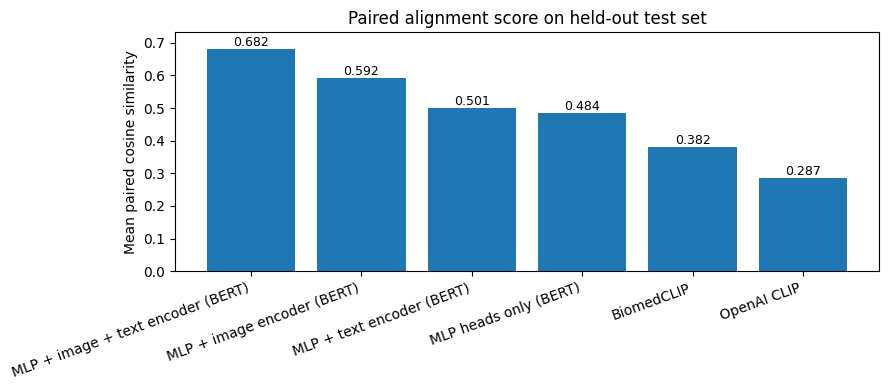

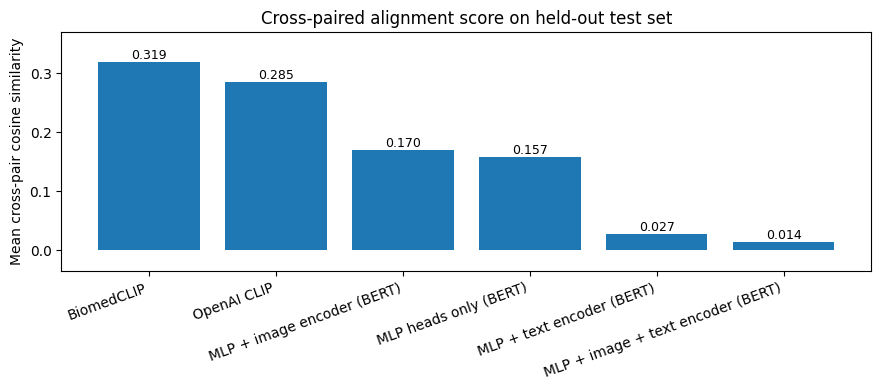

In [12]:

plot_df = alignment_results.copy()

# Plot 1: paired alignment score
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(plot_df["model"], plot_df["paired_similarity"])
ax.set_ylabel("Mean paired cosine similarity")
ax.set_title("Paired alignment score on held-out test set")
ax.set_ylim(min(0, plot_df["paired_similarity"].min() - 0.05),
            plot_df["paired_similarity"].max() + 0.05)
plt.xticks(rotation=20, ha="right")
for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

# Plot 2: cross-paired alignment score
cross_plot_df = alignment_results.sort_values("cross_pair_similarity", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cross_plot_df["model"], cross_plot_df["cross_pair_similarity"])
ax.set_ylabel("Mean cross-pair cosine similarity")
ax.set_title("Cross-paired alignment score on held-out test set")
ax.set_ylim(min(0, cross_plot_df["cross_pair_similarity"].min() - 0.05),
            cross_plot_df["cross_pair_similarity"].max() + 0.05)
plt.xticks(rotation=20, ha="right")
for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()


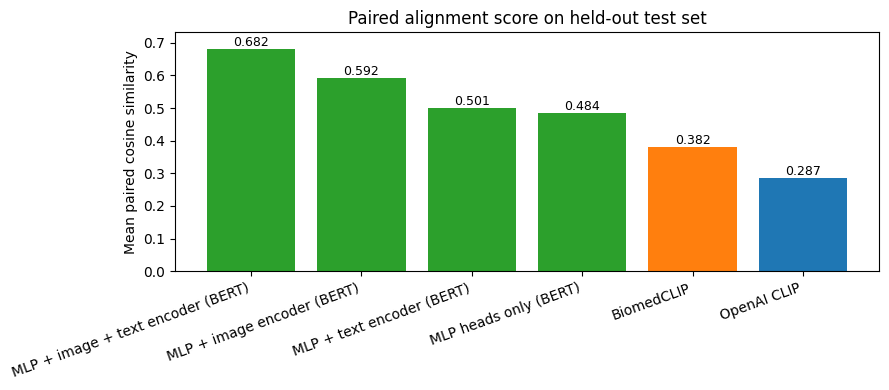

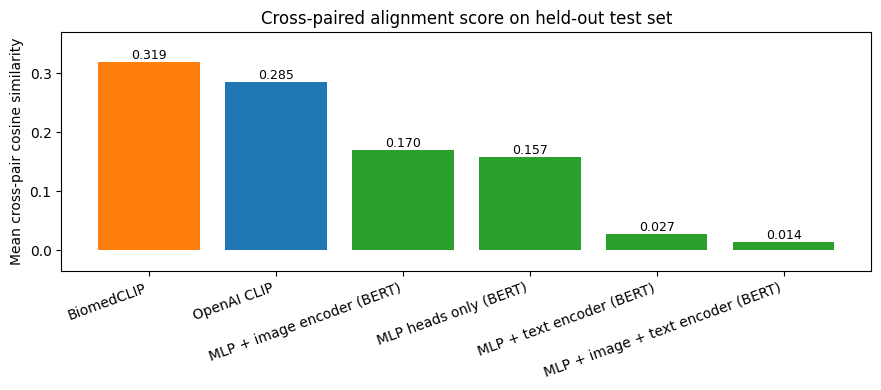

In [13]:
# Define colors per model (edit names if needed)
model_colors = {
    "OpenAI CLIP": "#1f77b4",
    "BiomedCLIP": "#ff7f0e",
    "MLP head only": "#2ca02c",
    "Image encoder finetuned": "#d62728",
    "Text encoder finetuned": "#9467bd",
}

# Default color for trained models
default_trained_color = "#2ca02c"  # green

def get_colors(models):
    return [
        model_colors[m] if m in model_colors else default_trained_color
        for m in models
    ]


# -----------------------
# Plot 1: paired alignment
# -----------------------
plot_df = alignment_results.copy()
colors = get_colors(plot_df["model"])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(plot_df["model"], plot_df["paired_similarity"], color=colors)

ax.set_ylabel("Mean paired cosine similarity")
ax.set_title("Paired alignment score on held-out test set")

ax.set_ylim(
    min(0, plot_df["paired_similarity"].min() - 0.05),
    plot_df["paired_similarity"].max() + 0.05
)

plt.xticks(rotation=20, ha="right")

for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


# -----------------------
# Plot 2: cross-paired alignment
# -----------------------
cross_plot_df = alignment_results.sort_values("cross_pair_similarity", ascending=False).reset_index(drop=True)
colors = get_colors(cross_plot_df["model"])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cross_plot_df["model"], cross_plot_df["cross_pair_similarity"], color=colors)

ax.set_ylabel("Mean cross-pair cosine similarity")
ax.set_title("Cross-paired alignment score on held-out test set")

ax.set_ylim(
    min(0, cross_plot_df["cross_pair_similarity"].min() - 0.05),
    cross_plot_df["cross_pair_similarity"].max() + 0.05
)

plt.xticks(rotation=20, ha="right")

for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

## Classification via image-to-label prompt alignment (labeled test subset only)

Classification is evaluated only on `labeled_test_df`, which is the subset of the held-out test split that contains valid labels. This keeps the split consistent with `experiment_Mar21.ipynb` while avoiding unlabeled datasets during label-prompt evaluation.

In [14]:

if len(labeled_test_df) == 0:
    raise ValueError("No labeled rows are available in the held-out test split, so classification cannot be evaluated.")

label_names = sorted(labeled_test_df["label"].dropna().astype(str).str.lower().unique().tolist())
label_prompts = {label: build_label_prompt(label) for label in label_names}

print("Label prompts used for classification:")
for label, prompt in label_prompts.items():
    print(f"  {label:12s} -> {prompt}")


Label prompts used for classification:
  benign       -> An ultrasound image of breast with benign findings.
  covid        -> An ultrasound image of breast with covid findings.
  healthy      -> An ultrasound image of breast with healthy findings.
  malignant    -> An ultrasound image of breast with malignant findings.
  normal       -> An ultrasound image of breast with normal findings.
  other        -> An ultrasound image of breast with other findings.


In [15]:
classification_rows = []
classification_details = {}

# OpenAI CLIP
acc, y_true, y_pred = classify_with_openai_clip(
    labeled_test_df, label_prompts, openai_clip_model, openai_clip_processor, device, batch_size=config["batch_size"]
)
classification_rows.append({"model": "OpenAI CLIP", "accuracy": acc})
classification_details["OpenAI CLIP"] = (y_true, y_pred)

# BiomedCLIP
acc, y_true, y_pred = classify_with_biomedclip(
    labeled_test_df, label_prompts, biomedclip_model, biomedclip_preprocess, biomedclip_tokenizer, device, batch_size=config["batch_size"]
)
classification_rows.append({"model": "BiomedCLIP", "accuracy": acc})
classification_details["BiomedCLIP"] = (y_true, y_pred)

# Trained models
for model_name, model in trained_models.items():
    acc, y_true, y_pred = classify_with_trained_model(
        model, labeled_test_loader, label_prompts, tokenizer, device
    )
    classification_rows.append({"model": model_name, "accuracy": acc})
    classification_details[model_name] = (y_true, y_pred)

classification_results = pd.DataFrame(classification_rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
classification_results

OpenAI CLIP classification:   0%|          | 0/63 [00:00<?, ?it/s]

BiomedCLIP classification:   0%|          | 0/63 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/63 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/63 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/63 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/63 [00:00<?, ?it/s]

,model,accuracy
0,MLP + image + text encoder (BERT),0.494995
1,MLP + image encoder (BERT),0.492492
2,MLP heads only (BERT),0.447447
3,BiomedCLIP,0.413914
4,MLP + text encoder (BERT),0.335335
5,OpenAI CLIP,0.039540


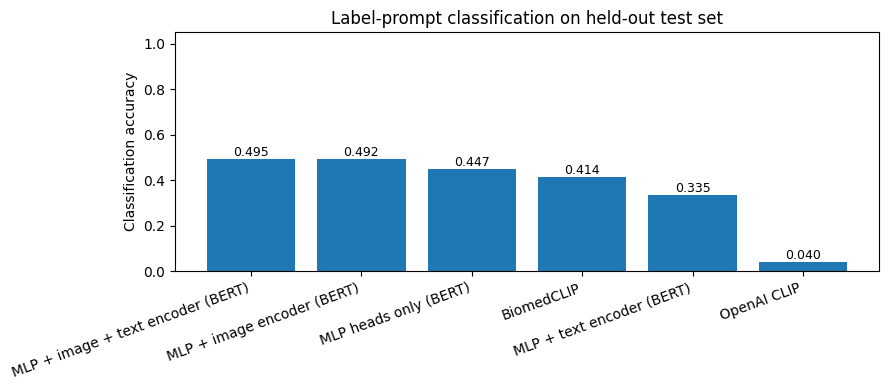

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(classification_results["model"], classification_results["accuracy"])
ax.set_ylabel("Classification accuracy")
ax.set_title("Label-prompt classification on held-out test set")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

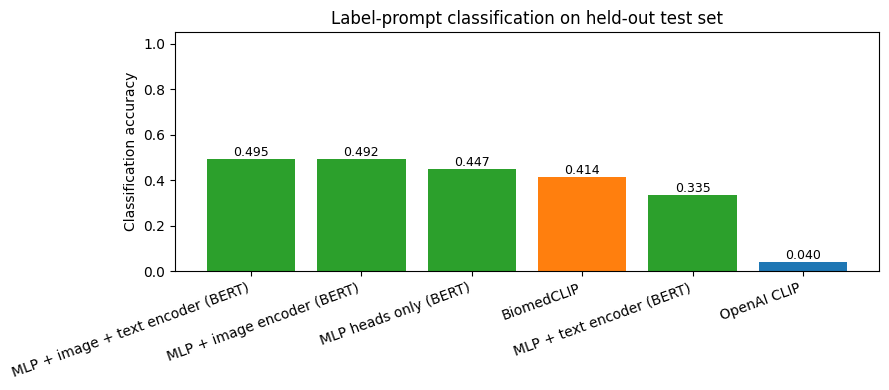

In [17]:
# Define colors (same mapping as alignment plots)
model_colors = {
    "OpenAI CLIP": "#1f77b4",
    "BiomedCLIP": "#ff7f0e",
    "MLP head only": "#2ca02c",
    "Image encoder finetuned": "#d62728",
    "Text encoder finetuned": "#9467bd",
}

default_trained_color = "#2ca02c"  # green

def get_colors(models):
    return [
        model_colors[m] if m in model_colors else default_trained_color
        for m in models
    ]

# Get colors
colors = get_colors(classification_results["model"])

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(classification_results["model"], classification_results["accuracy"], color=colors)

ax.set_ylabel("Classification accuracy")
ax.set_title("Label-prompt classification on held-out test set")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=20, ha="right")

for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Optional: inspect per-model classification reports

In [18]:
for model_name in classification_results["model"].tolist():
    print("=" * 80)
    print(model_name)
    y_true, y_pred = classification_details[model_name]
    print(classification_report(y_true, y_pred, digits=4))

MLP + image + text encoder (BERT)
              precision    recall  f1-score   support

      benign     0.4218    0.2693    0.3287       531
       covid     0.1151    0.9796    0.2060        49
     healthy     0.0000    0.0000    0.0000        55
   malignant     0.5254    0.4253    0.4701       609
      normal     0.8851    0.7711    0.8242       699
       other     0.0000    0.0000    0.0000        55

    accuracy                         0.4950      1998
   macro avg     0.3246    0.4075    0.3048      1998
weighted avg     0.5847    0.4950    0.5240      1998

MLP + image encoder (BERT)
              precision    recall  f1-score   support

      benign     0.3051    0.1902    0.2343       531
       covid     0.1378    0.6327    0.2263        49
     healthy     0.5301    0.8000    0.6377        55
   malignant     0.4966    0.3596    0.4171       609
      normal     0.9329    0.8355    0.8815       699
       other     0.0171    0.0909    0.0288        55

    accuracy    

In [19]:
# Save summary tables
results_dir = Path("/kaggle/working/results")
results_dir.mkdir(parents=True, exist_ok=True)

alignment_results.to_csv(results_dir / "alignment_results.csv", index=False)
classification_results.to_csv(results_dir / "classification_results.csv", index=False)

print("Saved:")
print(" ", results_dir / "alignment_results.csv")
print(" ", results_dir / "classification_results.csv")

Saved:
  /kaggle/working/results/alignment_results.csv
  /kaggle/working/results/classification_results.csv


## Extra imports, split prep, organ inference

In [27]:
from collections import defaultdict

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score

config.update({
    "fewshot_fracs": [0.01, 0.05, 0.10],
    "fewshot_num_seeds": 5,
    "linear_probe_c_grid": [0.01, 0.1, 1.0, 10.0],
    "probe_max_iter": 3000,
})

def infer_organ_from_dataset(dataset_name: str) -> str:
    s = str(dataset_name).strip().lower()

    if ("busi" in s) or ("breast" in s):
        return "breast"
    if "lung" in s:
        return "lung"
    if ("auli" in s) or ("liver" in s):
        return "liver"
    if ("auitd" in s) or ("thyroid" in s):
        return "thyroid"
    if ("artery" in s) or ("carotid" in s):
        return "carotid"

    return "unknown"

def prepare_labeled_eval_df(df, keep_unknown_organs=False):
    out = df.copy().reset_index(drop=True)

    out["label"] = out["label"].astype(str).str.strip().str.lower()
    out = out[~out["label"].isin(["", "nan", "none", "unknown"])].copy()

    out["organ"] = out["dataset"].apply(infer_organ_from_dataset)
    if not keep_unknown_organs:
        out = out[out["organ"] != "unknown"].copy()

    out = out.reset_index(drop=True)
    out["row_id"] = np.arange(len(out))
    return out

labeled_train_df = prepare_labeled_eval_df(train_df)
labeled_val_df   = prepare_labeled_eval_df(val_df)
labeled_test_df  = prepare_labeled_eval_df(test_df)

print("Labeled train/val/test sizes:")
print("  train:", len(labeled_train_df))
print("  val  :", len(labeled_val_df))
print("  test :", len(labeled_test_df))

print("\nPer-organ train counts:")
print(labeled_train_df["organ"].value_counts())

print("\nPer-organ label counts in test split:")
print(labeled_test_df.groupby("organ")["label"].value_counts())

Labeled train/val/test sizes:
  train: 7911
  val  : 1695
  test : 1695

Per-organ train counts:
organ
thyroid    5042
liver      1952
lung        743
breast      174
Name: count, dtype: int64

Per-organ label counts in test split:
organ    label    
breast   benign        21
         malignant     14
         normal         2
liver    <na>         343
         normal        75
lung     healthy       55
         other         55
         covid         49
thyroid  normal       622
         malignant    241
         <na>         129
         benign        89
Name: count, dtype: int64


## Embedding extraction + probe helpers

In [28]:
def make_eval_loader(df):
    ds = LabeledUltrasoundDataset(df, split="test")
    return DataLoader(
        ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=(device.type == "cuda"),
    )

@torch.no_grad()
def extract_trained_embeddings(model, df):
    loader = make_eval_loader(df)
    chunks = []
    model.eval()

    for images, _, _, _, _ in tqdm(loader, desc="Trained emb", leave=False):
        images = images.to(device)
        emb = model.encode_image(images)
        chunks.append(emb.cpu().numpy())

    return np.concatenate(chunks, axis=0)

@torch.no_grad()
def extract_openai_clip_embeddings(df, model, processor):
    model.eval()
    chunks = []

    for start in tqdm(range(0, len(df), config["batch_size"]), desc="OpenAI emb", leave=False):
        batch_df = df.iloc[start:start + config["batch_size"]]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]

        img_inputs = processor(images=pil_images, return_tensors="pt").to(device)

        # More robust than model.get_image_features(...) across notebook/library variants
        vision_out = model.vision_model(pixel_values=img_inputs["pixel_values"])
        pooled = vision_out.pooler_output                    # (B, hidden_dim)
        feats = model.visual_projection(pooled)              # (B, projection_dim)
        feats = F.normalize(feats, dim=-1)

        chunks.append(feats.cpu().numpy())

    return np.concatenate(chunks, axis=0)

@torch.no_grad()
def extract_biomedclip_embeddings(df, model, preprocess):
    chunks = []

    for start in tqdm(range(0, len(df), config["batch_size"]), desc="Biomed emb", leave=False):
        batch_df = df.iloc[start:start + config["batch_size"]]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        images = torch.stack([preprocess(img) for img in pil_images]).to(device)

        feats = model.encode_image(images)
        feats = F.normalize(feats, dim=-1)

        chunks.append(feats.cpu().numpy())

    return np.concatenate(chunks, axis=0)

def sample_fewshot_per_class(df, frac, seed, label_col="label"):
    pieces = []

    for label, group in df.groupby(label_col):
        n = int(np.ceil(len(group) * frac))
        if len(group) >= 2:
            n = max(2, n)   # avoid one-example classes whenever possible
        else:
            n = 1
        n = min(len(group), n)

        pieces.append(group.sample(n=n, random_state=seed))

    out = pd.concat(pieces, axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def multiclass_metrics(y_true, y_pred, y_prob, class_names):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        if len(class_names) == 2:
            pos_class = class_names[1]
            y_true_bin = (np.asarray(y_true) == pos_class).astype(int)
            pos_idx = list(class_names).index(pos_class)
            out["auroc"] = roc_auc_score(y_true_bin, y_prob[:, pos_idx])
        else:
            y_bin = label_binarize(y_true, classes=class_names)
            out["auroc"] = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        out["auroc"] = np.nan

    return out

def fit_best_linear_probe(train_X, train_y, val_X=None, val_y=None, c_grid=None, seed=42):
    c_grid = c_grid or config["linear_probe_c_grid"]

    label_encoder = LabelEncoder()
    label_encoder.fit(train_y)
    y_train = label_encoder.transform(train_y)

    best_model = None
    best_score = -np.inf
    best_c = None

    for c in c_grid:
        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                C=c,
                max_iter=config["probe_max_iter"],
                class_weight="balanced",
                solver="lbfgs",
                multi_class="auto",
                random_state=seed,
            )),
        ])

        clf.fit(train_X, y_train)

        if val_X is None or val_y is None or len(val_y) == 0:
            score = 0.0
        else:
            val_mask = np.isin(val_y, label_encoder.classes_)
            if val_mask.sum() == 0:
                score = 0.0
            else:
                y_val = label_encoder.transform(np.asarray(val_y)[val_mask])
                val_pred = clf.predict(val_X[val_mask])
                score = f1_score(y_val, val_pred, average="weighted", zero_division=0)

        if score > best_score:
            best_score = score
            best_model = clf
            best_c = c

    return best_model, label_encoder, best_c, best_score

def evaluate_linear_probe_on_split(clf, label_encoder, X, y):
    y = np.asarray(y)
    keep = np.isin(y, label_encoder.classes_)

    X = X[keep]
    y = y[keep]

    y_pred_int = clf.predict(X)
    y_prob = clf.predict_proba(X)
    y_pred = label_encoder.inverse_transform(y_pred_int)

    metrics = multiclass_metrics(y, y_pred, y_prob, label_encoder.classes_)
    metrics["n_eval"] = int(len(y))
    return metrics

def run_per_organ_probe(train_meta, train_X, val_meta, val_X, test_meta, test_X,
                        fewshot_frac=None, fewshot_seed=42):
    rows = []

    organs = sorted(set(train_meta["organ"]) & set(val_meta["organ"]) & set(test_meta["organ"]))

    for organ in organs:
        tr = train_meta[train_meta["organ"] == organ].copy()
        va = val_meta[val_meta["organ"] == organ].copy()
        te = test_meta[test_meta["organ"] == organ].copy()

        # Require at least 2 training examples per class in the full train split
        train_counts = tr["label"].value_counts()
        keep_classes = train_counts[train_counts >= 2].index.tolist()

        tr = tr[tr["label"].isin(keep_classes)].copy()
        va = va[va["label"].isin(keep_classes)].copy()
        te = te[te["label"].isin(keep_classes)].copy()

        if tr["label"].nunique() < 2 or len(te) == 0:
            print(f"Skipping organ={organ} because there are not enough train/test classes after filtering.")
            continue

        if fewshot_frac is not None:
            tr = sample_fewshot_per_class(tr, frac=fewshot_frac, seed=fewshot_seed, label_col="label")

        X_tr = train_X[tr["row_id"].to_numpy()]
        y_tr = tr["label"].to_numpy()

        X_va = val_X[va["row_id"].to_numpy()]
        y_va = va["label"].to_numpy()

        X_te = test_X[te["row_id"].to_numpy()]
        y_te = te["label"].to_numpy()

        clf, le, best_c, best_val_f1 = fit_best_linear_probe(
            X_tr, y_tr,
            X_va, y_va,
            c_grid=config["linear_probe_c_grid"],
            seed=fewshot_seed,
        )

        test_metrics = evaluate_linear_probe_on_split(clf, le, X_te, y_te)

        rows.append({
            "organ": organ,
            "n_train": len(tr),
            "n_val": len(va),
            "n_test": len(te),
            "n_classes": len(le.classes_),
            "best_c": best_c,
            "val_f1_weighted": best_val_f1,
            **test_metrics,
        })

    return pd.DataFrame(rows)

def summarize_across_organs(per_organ_df):
    if per_organ_df.empty:
        return pd.DataFrame(columns=["average_type", "auroc", "accuracy", "f1_weighted", "n_organs"])

    rows = []
    weights = per_organ_df["n_eval"].to_numpy()

    for avg_name in ["macro", "weighted_by_test_n"]:
        row = {"average_type": avg_name, "n_organs": int(len(per_organ_df))}

        for metric in ["auroc", "accuracy", "f1_weighted"]:
            vals = per_organ_df[metric].to_numpy(dtype=float)
            mask = ~np.isnan(vals)

            if mask.sum() == 0:
                row[metric] = np.nan
            elif avg_name == "macro":
                row[metric] = vals[mask].mean()
            else:
                row[metric] = np.average(vals[mask], weights=weights[mask])

        rows.append(row)

    return pd.DataFrame(rows)

## Extract embeddings for every model and split

In [29]:
model_registry = {
    "OpenAI CLIP": {"kind": "openai", "model": openai_clip_model},
    "BiomedCLIP": {"kind": "biomedclip", "model": biomedclip_model},
}
for model_name, model in trained_models.items():
    model_registry[model_name] = {"kind": "trained", "model": model}

eval_splits = {
    "train": labeled_train_df,
    "val": labeled_val_df,
    "test": labeled_test_df,
}

embedding_bank = defaultdict(dict)

for model_name, spec in model_registry.items():
    print(f"\nExtracting embeddings for: {model_name}")

    for split_name, split_df in eval_splits.items():
        if spec["kind"] == "trained":
            X = extract_trained_embeddings(spec["model"], split_df)
        elif spec["kind"] == "openai":
            X = extract_openai_clip_embeddings(split_df, openai_clip_model, openai_clip_processor)
        elif spec["kind"] == "biomedclip":
            X = extract_biomedclip_embeddings(split_df, biomedclip_model, biomedclip_preprocess)
        else:
            raise ValueError(f"Unknown model kind: {spec['kind']}")

        embedding_bank[model_name][split_name] = {
            "X": X,
            "meta": split_df.copy().reset_index(drop=True),
        }

        print(f"  {split_name:>5s}: {X.shape}")


Extracting embeddings for: OpenAI CLIP


OpenAI emb:   0%|          | 0/248 [00:00<?, ?it/s]

  train: (7911, 512)


OpenAI emb:   0%|          | 0/53 [00:00<?, ?it/s]

    val: (1695, 512)


...

  train: (7911, 256)


Trained emb:   0%|          | 0/53 [00:00<?, ?it/s]

    val: (1695, 256)


Trained emb:   0%|          | 0/53 [00:00<?, ?it/s]

   test: (1695, 256)


## Full linear probe evaluation

In [30]:
linear_probe_per_organ = []
linear_probe_aggregate = []

for model_name in model_registry:
    print(f"\nRunning full linear probe for: {model_name}")

    train_pack = embedding_bank[model_name]["train"]
    val_pack   = embedding_bank[model_name]["val"]
    test_pack  = embedding_bank[model_name]["test"]

    per_organ = run_per_organ_probe(
        train_pack["meta"], train_pack["X"],
        val_pack["meta"],   val_pack["X"],
        test_pack["meta"],  test_pack["X"],
        fewshot_frac=None,
        fewshot_seed=config["random_seed"],
    )
    per_organ["model"] = model_name
    per_organ["setting"] = "linear_probe"
    linear_probe_per_organ.append(per_organ)

    agg = summarize_across_organs(per_organ)
    agg["model"] = model_name
    agg["setting"] = "linear_probe"
    linear_probe_aggregate.append(agg)

linear_probe_per_organ = pd.concat(linear_probe_per_organ, ignore_index=True)
linear_probe_aggregate = pd.concat(linear_probe_aggregate, ignore_index=True)

print("\nPer-organ linear probe results:")
linear_probe_per_organ.sort_values(["model", "organ"])[
    ["model", "organ", "auroc", "accuracy", "f1_weighted", "n_train", "n_test", "n_classes"]
]

print("\nAggregate linear probe results:")
linear_probe_aggregate.sort_values(["average_type", "auroc"], ascending=[True, False])[
    ["model", "average_type", "auroc", "accuracy", "f1_weighted", "n_organs"]
]


Running full linear probe for: OpenAI CLIP

Running full linear probe for: BiomedCLIP

Running full linear probe for: MLP heads only (BERT)

Running full linear probe for: MLP + image encoder (BERT)

Running full linear probe for: MLP + text encoder (BERT)

Running full linear probe for: MLP + image + text encoder (BERT)

Per-organ linear probe results:

Aggregate linear probe results:


,model,average_type,auroc,accuracy,f1_weighted,n_organs
2,BiomedCLIP,macro,0.809407,0.694459,0.703082,4
0,OpenAI CLIP,macro,0.800234,0.672153,0.680671,4
4,MLP heads only (BERT),macro,0.786320,0.655724,0.668243,4
10,MLP + image + text encoder (BERT),macro,0.784958,0.695570,0.705569,4
8,MLP + text encoder (BERT),macro,0.773897,0.652350,0.666665,4
6,MLP + image encoder (BERT),macro,0.770742,0.681695,0.692795,4
3,BiomedCLIP,weighted_by_test_n,0.840049,0.693215,0.716977,4
1,OpenAI CLIP,weighted_by_test_n,0.833168,0.673746,0.699414,4
11,MLP + image + text encoder (BERT),weighted_by_test_n,0.825433,0.679646,0.703963,4
7,MLP + image encoder (BERT),weighted_by_test_n,0.820733,0.664307,0.691520,4


## Few-shot adaptation evaluation

In [31]:
fewshot_raw_rows = []

for model_name in model_registry:
    print(f"\nFew-shot evaluation for: {model_name}")

    train_pack = embedding_bank[model_name]["train"]
    val_pack   = embedding_bank[model_name]["val"]
    test_pack  = embedding_bank[model_name]["test"]

    for frac in config["fewshot_fracs"]:
        print(f"  fraction = {frac:.0%}")

        for rep in range(config["fewshot_num_seeds"]):
            seed = config["random_seed"] + rep

            per_organ = run_per_organ_probe(
                train_pack["meta"], train_pack["X"],
                val_pack["meta"],   val_pack["X"],
                test_pack["meta"],  test_pack["X"],
                fewshot_frac=frac,
                fewshot_seed=seed,
            )

            per_organ["model"] = model_name
            per_organ["setting"] = "fewshot_adaptation"
            per_organ["fewshot_frac"] = frac
            per_organ["seed"] = seed

            fewshot_raw_rows.append(per_organ)

fewshot_per_organ_raw = pd.concat(fewshot_raw_rows, ignore_index=True)

fewshot_per_organ_summary = (
    fewshot_per_organ_raw
    .groupby(["model", "setting", "fewshot_frac", "organ"], as_index=False)
    .agg(
        auroc_mean=("auroc", "mean"),
        auroc_std=("auroc", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_weighted_mean=("f1_weighted", "mean"),
        f1_weighted_std=("f1_weighted", "std"),
        n_train_mean=("n_train", "mean"),
        n_test_mean=("n_test", "mean"),
        n_classes_mean=("n_classes", "mean"),
    )
)

fewshot_aggregate_rows = []

for (model_name, frac, seed), df_seed in fewshot_per_organ_raw.groupby(["model", "fewshot_frac", "seed"]):
    agg = summarize_across_organs(df_seed)
    agg["model"] = model_name
    agg["setting"] = "fewshot_adaptation"
    agg["fewshot_frac"] = frac
    agg["seed"] = seed
    fewshot_aggregate_rows.append(agg)

fewshot_aggregate_raw = pd.concat(fewshot_aggregate_rows, ignore_index=True)

fewshot_aggregate_summary = (
    fewshot_aggregate_raw
    .groupby(["model", "setting", "fewshot_frac", "average_type"], as_index=False)
    .agg(
        auroc_mean=("auroc", "mean"),
        auroc_std=("auroc", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_weighted_mean=("f1_weighted", "mean"),
        f1_weighted_std=("f1_weighted", "std"),
        n_organs_mean=("n_organs", "mean"),
    )
)

print("\nFew-shot aggregate summary:")
fewshot_aggregate_summary.sort_values(
    ["average_type", "fewshot_frac", "auroc_mean"],
    ascending=[True, True, False]
)[
    ["model", "fewshot_frac", "average_type",
     "auroc_mean", "auroc_std",
     "accuracy_mean", "accuracy_std",
     "f1_weighted_mean", "f1_weighted_std"]
]


Few-shot evaluation for: OpenAI CLIP
  fraction = 1%
  fraction = 5%
  fraction = 10%

Few-shot evaluation for: BiomedCLIP
  fraction = 1%
  fraction = 5%
  fraction = 10%

Few-shot evaluation for: MLP heads only (BERT)
  fraction = 1%
  fraction = 5%
  fraction = 10%

Few-shot evaluation for: MLP + image encoder (BERT)
  fraction = 1%
  fraction = 5%
  fraction = 10%

Few-shot evaluation for: MLP + text encoder (BERT)
  fraction = 1%
  fraction = 5%
  fraction = 10%

Few-shot evaluation for: MLP + image + text encoder (BERT)
  fraction = 1%
  fraction = 5%
  fraction = 10%

Few-shot aggregate summary:


,model,fewshot_frac,average_type,auroc_mean,auroc_std,accuracy_mean,accuracy_std,f1_weighted_mean,f1_weighted_std
18,MLP + text encoder (BERT),0.01,macro,0.710748,0.023646,0.613225,0.007599,0.603516,0.010072
30,OpenAI CLIP,0.01,macro,0.706733,0.017463,0.614213,0.025090,0.606242,0.028278
24,MLP heads only (BERT),0.01,macro,0.693827,0.018019,0.589492,0.024507,0.587044,0.022400
0,BiomedCLIP,0.01,macro,0.692599,0.023327,0.630035,0.032254,0.625657,0.033923
6,MLP + image + text encoder (BERT),0.01,macro,0.692478,0.016510,0.591098,0.021982,0.600595,0.026151
12,MLP + image encoder (BERT),0.01,macro,0.671625,0.019506,0.607710,0.021072,0.609883,0.012570
32,OpenAI CLIP,0.05,macro,0.745584,0.011090,0.667053,0.010268,0.667075,0.007226
2,BiomedCLIP,0.05,macro,0.744104,0.021161,0.662923,0.034617,0.663722,0.029738
20,MLP + text encoder (BERT),0.05,macro,0.732226,0.022911,0.637777,0.022915,0.643198,0.019884
26,MLP heads only (BERT),0.05,macro,0.712076,0.022211,0.623854,0.031883,0.633092,0.026955


## Cell 6 — save tables and make simple plots

Saved to: /kaggle/working/heldout_probe_eval


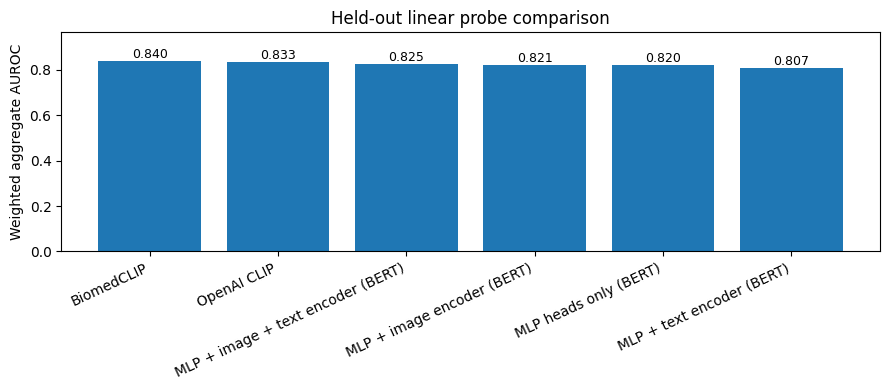

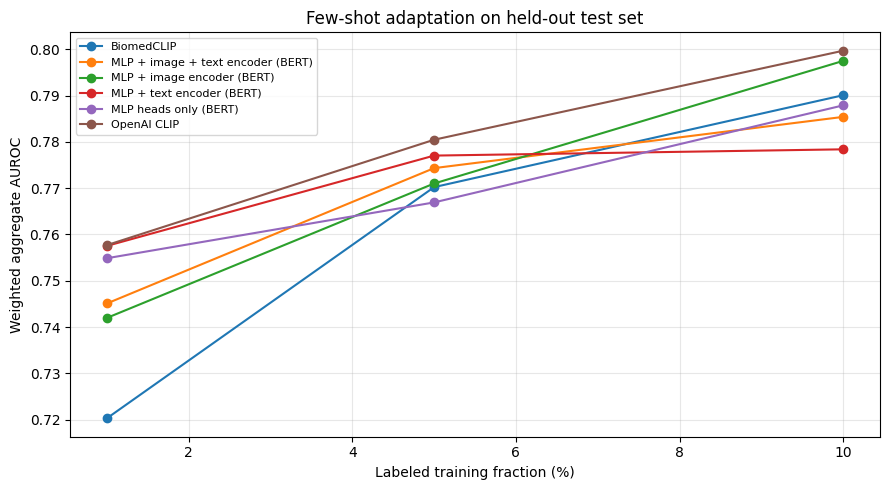

In [32]:
results_dir = Path("/kaggle/working/heldout_probe_eval")
results_dir.mkdir(parents=True, exist_ok=True)

linear_probe_per_organ.to_csv(results_dir / "linear_probe_per_organ.csv", index=False)
linear_probe_aggregate.to_csv(results_dir / "linear_probe_aggregate.csv", index=False)

fewshot_per_organ_raw.to_csv(results_dir / "fewshot_per_organ_raw.csv", index=False)
fewshot_per_organ_summary.to_csv(results_dir / "fewshot_per_organ_summary.csv", index=False)

fewshot_aggregate_raw.to_csv(results_dir / "fewshot_aggregate_raw.csv", index=False)
fewshot_aggregate_summary.to_csv(results_dir / "fewshot_aggregate_summary.csv", index=False)

print("Saved to:", results_dir)

# --- Plot 1: full linear probe aggregate AUROC ---
plot_df = linear_probe_aggregate[
    linear_probe_aggregate["average_type"] == "weighted_by_test_n"
].copy().sort_values("auroc", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(plot_df["model"], plot_df["auroc"])
ax.set_ylabel("Weighted aggregate AUROC")
ax.set_title("Held-out linear probe comparison")
ax.set_ylim(0, min(1.0, max(0.05, plot_df["auroc"].max() * 1.15)))
plt.xticks(rotation=25, ha="right")

for b in bars:
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# --- Plot 2: few-shot weighted aggregate AUROC curves ---
plot_df = fewshot_aggregate_summary[
    fewshot_aggregate_summary["average_type"] == "weighted_by_test_n"
].copy()

fig, ax = plt.subplots(figsize=(9, 5))
for model_name in plot_df["model"].unique():
    sub = plot_df[plot_df["model"] == model_name].sort_values("fewshot_frac")
    ax.plot(sub["fewshot_frac"] * 100, sub["auroc_mean"], marker="o", label=model_name)

ax.set_xlabel("Labeled training fraction (%)")
ax.set_ylabel("Weighted aggregate AUROC")
ax.set_title("Few-shot adaptation on held-out test set")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Additional suggested tests

The core linear-probe / few-shot comparison is the right next step, but it is not enough by itself.

These extra tests are worth running because they answer different questions:

- **Retrieval quality on held-out image-caption pairs**: checks whether matched pairs rank above mismatched pairs, which is closer to the original alignment objective than plain classification.
- **Bootstrap confidence intervals**: shows whether small ranking differences are likely real or just split noise.
- **Confusion-matrix diagnostics**: shows *where* each model fails within each organ, instead of hiding all failures inside a single AUROC or F1.

None of these replaces external validation, but they make your internal evaluation much harder to hand-wave.

### Test 1 — Held-out retrieval metrics (image→text and text→image)

In [33]:
# Extra test: retrieval metrics on held-out paired image-caption examples

def compute_recall_at_k(sim_matrix, ks=(1, 5, 10)):
    """
    Assumes row i matches column i.
    Returns recall@k for row-to-column retrieval.
    """
    n = sim_matrix.shape[0]
    order = np.argsort(-sim_matrix, axis=1)
    out = {}
    targets = np.arange(n)

    for k in ks:
        topk = order[:, :min(k, n)]
        hit = (topk == targets[:, None]).any(axis=1)
        out[f"R@{k}"] = float(hit.mean())

    return out

@torch.no_grad()
def extract_trained_text_embeddings(model, texts, tokenizer, batch_size=32):
    model.eval()
    chunks = []

    for start in tqdm(range(0, len(texts), batch_size), desc="Trained text emb", leave=False):
        batch_texts = list(texts[start:start + batch_size])
        ids, mask = tokenize_texts(batch_texts, tokenizer, max_length=config["max_seq_len"], device=device)
        txt_emb = model.encode_text(ids, mask)
        chunks.append(txt_emb.cpu().numpy())

    return np.concatenate(chunks, axis=0)

@torch.no_grad()
def extract_openai_clip_text_embeddings(texts, model, processor, batch_size=32):
    model.eval()
    chunks = []

    for start in tqdm(range(0, len(texts), batch_size), desc="OpenAI text emb", leave=False):
        batch_texts = list(texts[start:start + batch_size])
        text_inputs = processor(text=batch_texts, return_tensors="pt", padding=True, truncation=True).to(device)

        txt_out = model.text_model(
            input_ids=text_inputs["input_ids"],
            attention_mask=text_inputs["attention_mask"],
        )
        pooled = txt_out.pooler_output
        feats = model.text_projection(pooled)
        feats = F.normalize(feats, dim=-1)

        chunks.append(feats.cpu().numpy())

    return np.concatenate(chunks, axis=0)

@torch.no_grad()
def extract_biomedclip_text_embeddings(texts, model, tokenizer, batch_size=32):
    model.eval()
    chunks = []

    for start in tqdm(range(0, len(texts), batch_size), desc="Biomed text emb", leave=False):
        batch_texts = list(texts[start:start + batch_size])
        text_inputs = tokenizer(batch_texts, context_length=256).to(device)
        feats = model.encode_text(text_inputs)
        feats = F.normalize(feats, dim=-1)
        chunks.append(feats.cpu().numpy())

    return np.concatenate(chunks, axis=0)

def run_retrieval_eval_for_model(model_name, spec, df):
    # image embeddings
    if spec["kind"] == "trained":
        img_X = extract_trained_embeddings(spec["model"], df)
        txt_X = extract_trained_text_embeddings(
            spec["model"], df["caption"].tolist(), tokenizer, batch_size=config["batch_size"]
        )
    elif spec["kind"] == "openai":
        img_X = extract_openai_clip_embeddings(df, openai_clip_model, openai_clip_processor)
        txt_X = extract_openai_clip_text_embeddings(
            df["caption"].tolist(), openai_clip_model, openai_clip_processor, batch_size=config["batch_size"]
        )
    elif spec["kind"] == "biomedclip":
        img_X = extract_biomedclip_embeddings(df, biomedclip_model, biomedclip_preprocess)
        txt_X = extract_biomedclip_text_embeddings(
            df["caption"].tolist(), biomedclip_model, biomedclip_tokenizer, batch_size=config["batch_size"]
        )
    else:
        raise ValueError(f"Unknown model kind: {spec['kind']}")

    sim = img_X @ txt_X.T
    i2t = compute_recall_at_k(sim, ks=(1, 5, 10))
    t2i = compute_recall_at_k(sim.T, ks=(1, 5, 10))

    row = {"model": model_name}
    row.update({f"image_to_text_{k}": v for k, v in i2t.items()})
    row.update({f"text_to_image_{k}": v for k, v in t2i.items()})
    return row

retrieval_rows = []
for model_name, spec in model_registry.items():
    print(f"Running retrieval metrics for {model_name}")
    retrieval_rows.append(run_retrieval_eval_for_model(model_name, spec, test_df))

retrieval_results = (
    pd.DataFrame(retrieval_rows)
    .sort_values(["image_to_text_R@1", "text_to_image_R@1"], ascending=False)
    .reset_index(drop=True)
)
retrieval_results

Running retrieval metrics for OpenAI CLIP


OpenAI emb:   0%|          | 0/78 [00:00<?, ?it/s]

OpenAI text emb:   0%|          | 0/78 [00:00<?, ?it/s]

Running retrieval metrics for BiomedCLIP


Biomed emb:   0%|          | 0/78 [00:00<?, ?it/s]

...

Trained text emb:   0%|          | 0/78 [00:00<?, ?it/s]

Running retrieval metrics for MLP + image + text encoder (BERT)


Trained emb:   0%|          | 0/78 [00:00<?, ?it/s]

Trained text emb:   0%|          | 0/78 [00:00<?, ?it/s]

,model,image_to_text_R@1,image_to_text_R@5,image_to_text_R@10,text_to_image_R@1,text_to_image_R@5,text_to_image_R@10
0,MLP + text encoder (BERT),0.027126,0.093522,0.151012,0.025911,0.093927,0.159919
1,MLP + image + text encoder (BERT),0.014170,0.064372,0.111741,0.014980,0.059514,0.112146
2,MLP heads only (BERT),0.008097,0.037247,0.056275,0.006073,0.033198,0.060729
3,BiomedCLIP,0.004858,0.015789,0.024291,0.005668,0.016194,0.031984
4,MLP + image encoder (BERT),0.004049,0.026721,0.047773,0.006073,0.027126,0.055870
5,OpenAI CLIP,0.000405,0.002834,0.006073,0.000405,0.003644,0.008907


### Test 2 — Bootstrap confidence intervals for held-out aggregate probe metrics

In [34]:
# Extra test: bootstrap confidence intervals for aggregate linear-probe metrics

def bootstrap_metric_ci(values, n_boot=1000, alpha=0.05, seed=42):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    boots = []
    n = len(values)

    for _ in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boots.append(sample.mean())

    boots = np.asarray(boots)
    mean = float(values.mean())
    lo = float(np.quantile(boots, alpha / 2))
    hi = float(np.quantile(boots, 1 - alpha / 2))
    return mean, lo, hi

ci_rows = []
agg_df = linear_probe_per_organ.copy()

for model_name, sub in agg_df.groupby("model"):
    for metric in ["auroc", "accuracy", "f1_weighted"]:
        mean, lo, hi = bootstrap_metric_ci(sub[metric].values, n_boot=1000, alpha=0.05, seed=config["random_seed"])
        ci_rows.append({
            "model": model_name,
            "setting": "linear_probe",
            "metric": metric,
            "mean": mean,
            "ci_lower": lo,
            "ci_upper": hi,
            "n_organs": int(sub["organ"].nunique()),
        })

linear_probe_ci = pd.DataFrame(ci_rows)
linear_probe_ci

,model,setting,metric,mean,ci_lower,ci_upper,n_organs
0,BiomedCLIP,linear_probe,auroc,0.809407,0.683856,0.934959,4
1,BiomedCLIP,linear_probe,accuracy,0.694459,0.618227,0.782764,4
2,BiomedCLIP,linear_probe,f1_weighted,0.703082,0.624565,0.791441,4
3,MLP + image + text encoder (BERT),linear_probe,auroc,0.784958,0.662959,0.906957,4
4,MLP + image + text encoder (BERT),linear_probe,accuracy,0.695570,0.668719,0.725891,4
5,MLP + image + text encoder (BERT),linear_probe,f1_weighted,0.705569,0.689720,0.727406,4
6,MLP + image encoder (BERT),linear_probe,auroc,0.770742,0.636601,0.904883,4
7,MLP + image encoder (BERT),linear_probe,accuracy,0.681695,0.631347,0.745174,4
8,MLP + image encoder (BERT),linear_probe,f1_weighted,0.692795,0.631872,0.754028,4
9,MLP + text encoder (BERT),linear_probe,auroc,0.773897,0.630404,0.908650,4


### Test 3 — Confusion matrices for the best held-out linear-probe models by organ

In [35]:
# Extra test: confusion-matrix diagnostics for the best linear-probe model in each organ

from sklearn.metrics import ConfusionMatrixDisplay

def fit_and_predict_probe_for_one_organ(model_name, organ):
    train_pack = embedding_bank[model_name]["train"]
    val_pack   = embedding_bank[model_name]["val"]
    test_pack  = embedding_bank[model_name]["test"]

    tr = train_pack["meta"][train_pack["meta"]["organ"] == organ].copy()
    va = val_pack["meta"][val_pack["meta"]["organ"] == organ].copy()
    te = test_pack["meta"][test_pack["meta"]["organ"] == organ].copy()

    train_counts = tr["label"].value_counts()
    keep_classes = train_counts[train_counts >= 2].index.tolist()

    tr = tr[tr["label"].isin(keep_classes)].copy()
    va = va[va["label"].isin(keep_classes)].copy()
    te = te[te["label"].isin(keep_classes)].copy()

    if tr["label"].nunique() < 2 or len(te) == 0:
        return None

    X_tr = train_pack["X"][tr["row_id"].to_numpy()]
    y_tr = tr["label"].to_numpy()

    X_va = val_pack["X"][va["row_id"].to_numpy()]
    y_va = va["label"].to_numpy()

    X_te = test_pack["X"][te["row_id"].to_numpy()]
    y_te = te["label"].to_numpy()

    clf, le, best_c, best_val_f1 = fit_best_linear_probe(
        X_tr, y_tr,
        X_va, y_va,
        c_grid=config["linear_probe_c_grid"],
        seed=config["random_seed"],
    )

    keep = np.isin(y_te, le.classes_)
    X_te = X_te[keep]
    y_te = y_te[keep]

    y_pred_int = clf.predict(X_te)
    y_pred = le.inverse_transform(y_pred_int)

    return {
        "y_true": y_te,
        "y_pred": y_pred,
        "labels": list(le.classes_),
        "best_c": best_c,
        "val_f1_weighted": best_val_f1,
    }

best_by_organ = (
    linear_probe_per_organ.sort_values(["organ", "f1_weighted"], ascending=[True, False])
    .groupby("organ", as_index=False)
    .first()[["organ", "model", "f1_weighted", "auroc", "accuracy"]]
)
best_by_organ

,organ,model,f1_weighted,auroc,accuracy
0,breast,MLP + image + text encoder (BERT),0.686902,0.729960,0.702703
1,liver,MLP + image encoder (BERT),0.711271,0.619475,0.684211
2,lung,BiomedCLIP,0.836279,0.959193,0.836478
3,thyroid,BiomedCLIP,0.726919,0.910725,0.704903


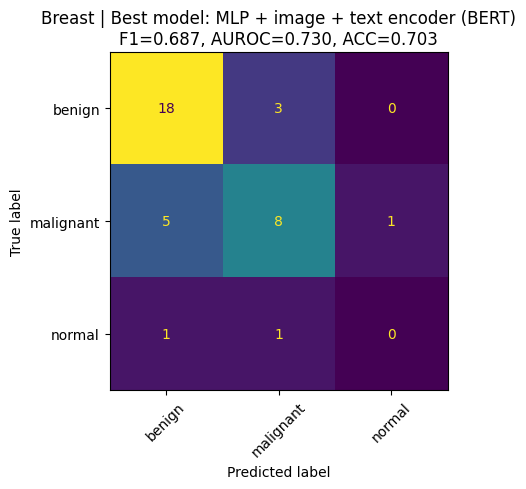

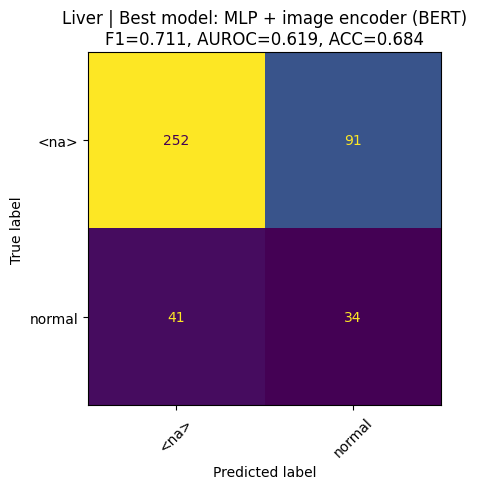

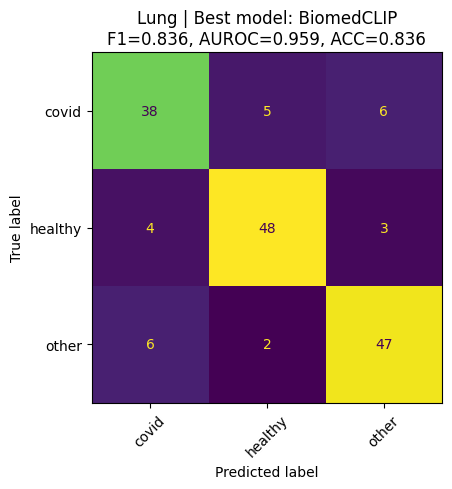

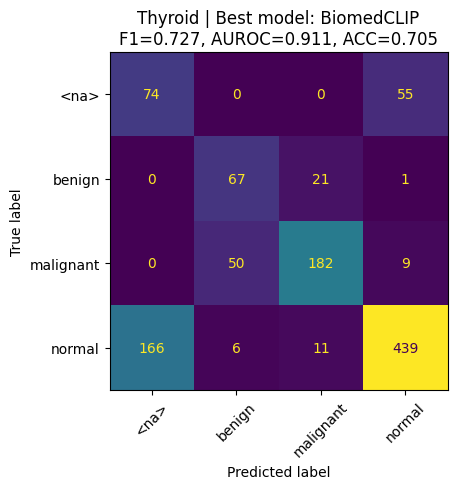

In [36]:
for _, row in best_by_organ.iterrows():
    organ = row["organ"]
    model_name = row["model"]

    out = fit_and_predict_probe_for_one_organ(model_name, organ)
    if out is None:
        print(f"Skipping {organ}: not enough data after filtering")
        continue

    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(
        out["y_true"],
        out["y_pred"],
        labels=out["labels"],
        xticks_rotation=45,
        ax=ax,
        colorbar=False,
    )
    ax.set_title(
        f"{organ.capitalize()} | Best model: {model_name}\n"
        f"F1={row['f1_weighted']:.3f}, AUROC={row['auroc']:.3f}, ACC={row['accuracy']:.3f}"
    )
    plt.tight_layout()
    plt.show()

## Additional analysis: per-organ and per-dataset classification

These added cells:
1. summarize the label space for each **organ** and **dataset** in the held-out labeled test split,
2. run the same prompt-based classification separately within each organ / dataset subset,
3. draw grouped bar plots with models clustered within each organ / dataset,
4. save the per-group results tables.

These cells do **not** modify any earlier cells; they only add extra analysis.


In [37]:

# Per-organ / per-dataset label-space summary

def summarize_group_label_space(df, group_col):
    rows = []
    for group_name, sub_df in df.groupby(group_col):
        labels = sorted(sub_df["label"].dropna().astype(str).str.lower().unique().tolist())
        rows.append({
            group_col: group_name,
            "n_samples": int(len(sub_df)),
            "labels": ", ".join(labels),
            "n_labels": int(len(labels)),
            "task_type": "binary" if len(labels) == 2 else ("single-class" if len(labels) == 1 else f"{len(labels)}-class"),
        })
    return pd.DataFrame(rows).sort_values([group_col]).reset_index(drop=True)

organ_label_space = summarize_group_label_space(labeled_test_df, "organ")
dataset_label_space = summarize_group_label_space(labeled_test_df, "dataset")

print("Per-organ label space in held-out labeled test set")
display(organ_label_space)

print("Per-dataset label space in held-out labeled test set")
display(dataset_label_space)


Per-organ label space in held-out labeled test set


,organ,n_samples,labels,n_labels,task_type
0,breast,37,"benign, malignant, normal",3,3-class
1,liver,418,"<na>, normal",2,binary
2,lung,159,"covid, healthy, other",3,3-class
3,thyroid,1081,"<na>, benign, malignant, normal",4,4-class


Per-dataset label space in held-out labeled test set


,dataset,n_samples,labels,n_labels,task_type
0,BrEaST-Lesions_USG-images_and_masks,37,"benign, malignant, normal",3,3-class
1,Liver USData (with Chinese annotation),418,"<na>, normal",2,binary
2,Lung_ultrasound,159,"covid, healthy, other",3,3-class
3,Thyroid,344,"benign, malignant, normal",3,3-class
4,Thyroid USData (with Chinese annotation),737,"<na>, normal",2,binary


In [38]:

# Separate prompt-based classification within each organ / dataset subset

def make_subset_labeled_loader(df):
    ds = LabeledUltrasoundDataset(df.reset_index(drop=True), split="test")
    return DataLoader(
        ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=(device.type == "cuda"),
    )

def get_model_device_fallback(model, default_device):
    try:
        return next(model.parameters()).device
    except StopIteration:
        return default_device
    except Exception:
        return default_device

openai_eval_device = get_model_device_fallback(openai_clip_model, device)
biomed_eval_device = get_model_device_fallback(biomedclip_model, device)

def evaluate_prompt_classification_by_group(df, group_col):
    rows = []
    details = {}

    for group_name, sub_df in sorted(df.groupby(group_col), key=lambda x: str(x[0])):
        sub_df = sub_df.reset_index(drop=True).copy()
        label_names = sorted(sub_df["label"].dropna().astype(str).str.lower().unique().tolist())

        # skip groups with <2 labels because "classification accuracy" is trivial / uninformative there
        if len(label_names) < 2:
            print(f"Skipping {group_col}={group_name!r} because it has <2 labels.")
            continue

        label_prompts = {label: build_label_prompt(label) for label in label_names}

        # OpenAI CLIP
        acc, y_true, y_pred = classify_with_openai_clip(
            sub_df, label_prompts, openai_clip_model, openai_clip_processor,
            openai_eval_device, batch_size=config["batch_size"]
        )
        rows.append({
            "group_type": group_col,
            "group_name": group_name,
            "model": "OpenAI CLIP",
            "accuracy": acc,
            "n_samples": int(len(sub_df)),
            "n_labels": int(len(label_names)),
            "labels": ", ".join(label_names),
        })
        details[(group_col, group_name, "OpenAI CLIP")] = (y_true, y_pred)

        # BiomedCLIP
        acc, y_true, y_pred = classify_with_biomedclip(
            sub_df, label_prompts, biomedclip_model, biomedclip_preprocess,
            biomedclip_tokenizer, biomed_eval_device, batch_size=config["batch_size"]
        )
        rows.append({
            "group_type": group_col,
            "group_name": group_name,
            "model": "BiomedCLIP",
            "accuracy": acc,
            "n_samples": int(len(sub_df)),
            "n_labels": int(len(label_names)),
            "labels": ", ".join(label_names),
        })
        details[(group_col, group_name, "BiomedCLIP")] = (y_true, y_pred)

        # Trained models
        subset_loader = make_subset_labeled_loader(sub_df)
        for model_name, model in trained_models.items():
            trained_eval_device = get_model_device_fallback(model, device)
            acc, y_true, y_pred = classify_with_trained_model(
                model, subset_loader, label_prompts, tokenizer, trained_eval_device
            )
            rows.append({
                "group_type": group_col,
                "group_name": group_name,
                "model": model_name,
                "accuracy": acc,
                "n_samples": int(len(sub_df)),
                "n_labels": int(len(label_names)),
                "labels": ", ".join(label_names),
            })
            details[(group_col, group_name, model_name)] = (y_true, y_pred)

    results = pd.DataFrame(rows)
    return results, details

per_organ_classification_results, per_organ_classification_details = evaluate_prompt_classification_by_group(
    labeled_test_df, "organ"
)

per_dataset_classification_results, per_dataset_classification_details = evaluate_prompt_classification_by_group(
    labeled_test_df, "dataset"
)

print("Per-organ classification results")
display(per_organ_classification_results.sort_values(["group_name", "accuracy"], ascending=[True, False]))

print("Per-dataset classification results")
display(per_dataset_classification_results.sort_values(["group_name", "accuracy"], ascending=[True, False]))


OpenAI CLIP classification:   0%|          | 0/2 [00:00<?, ?it/s]

BiomedCLIP classification:   0%|          | 0/2 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/2 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/2 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/2 [00:00<?, ?it/s]

...

Trained model classification:   0%|          | 0/24 [00:00<?, ?it/s]

Per-organ classification results


,group_type,group_name,model,accuracy,n_samples,n_labels,labels
0,organ,breast,OpenAI CLIP,0.459459,37,3,"benign, malignant, normal"
3,organ,breast,MLP + image encoder (BERT),0.432432,37,3,"benign, malignant, normal"
2,organ,breast,MLP heads only (BERT),0.405405,37,3,"benign, malignant, normal"
1,organ,breast,BiomedCLIP,0.351351,37,3,"benign, malignant, normal"
5,organ,breast,MLP + image + text encoder (BERT),0.351351,37,3,"benign, malignant, normal"
4,organ,breast,MLP + text encoder (BERT),0.270270,37,3,"benign, malignant, normal"
10,organ,liver,MLP + text encoder (BERT),0.612440,418,2,"<na>, normal"
6,organ,liver,OpenAI CLIP,0.576555,418,2,"<na>, normal"
7,organ,liver,BiomedCLIP,0.339713,418,2,"<na>, normal"
11,organ,liver,MLP + image + text encoder (BERT),0.234450,418,2,"<na>, normal"


Per-dataset classification results


,group_type,group_name,model,accuracy,n_samples,n_labels,labels
0,dataset,BrEaST-Lesions_USG-images_and_masks,OpenAI CLIP,0.459459,37,3,"benign, malignant, normal"
3,dataset,BrEaST-Lesions_USG-images_and_masks,MLP + image encoder (BERT),0.432432,37,3,"benign, malignant, normal"
2,dataset,BrEaST-Lesions_USG-images_and_masks,MLP heads only (BERT),0.405405,37,3,"benign, malignant, normal"
1,dataset,BrEaST-Lesions_USG-images_and_masks,BiomedCLIP,0.351351,37,3,"benign, malignant, normal"
5,dataset,BrEaST-Lesions_USG-images_and_masks,MLP + image + text encoder (BERT),0.351351,37,3,"benign, malignant, normal"
4,dataset,BrEaST-Lesions_USG-images_and_masks,MLP + text encoder (BERT),0.270270,37,3,"benign, malignant, normal"
10,dataset,Liver USData (with Chinese annotation),MLP + text encoder (BERT),0.612440,418,2,"<na>, normal"
6,dataset,Liver USData (with Chinese annotation),OpenAI CLIP,0.576555,418,2,"<na>, normal"
7,dataset,Liver USData (with Chinese annotation),BiomedCLIP,0.339713,418,2,"<na>, normal"
11,dataset,Liver USData (with Chinese annotation),MLP + image + text encoder (BERT),0.234450,418,2,"<na>, normal"


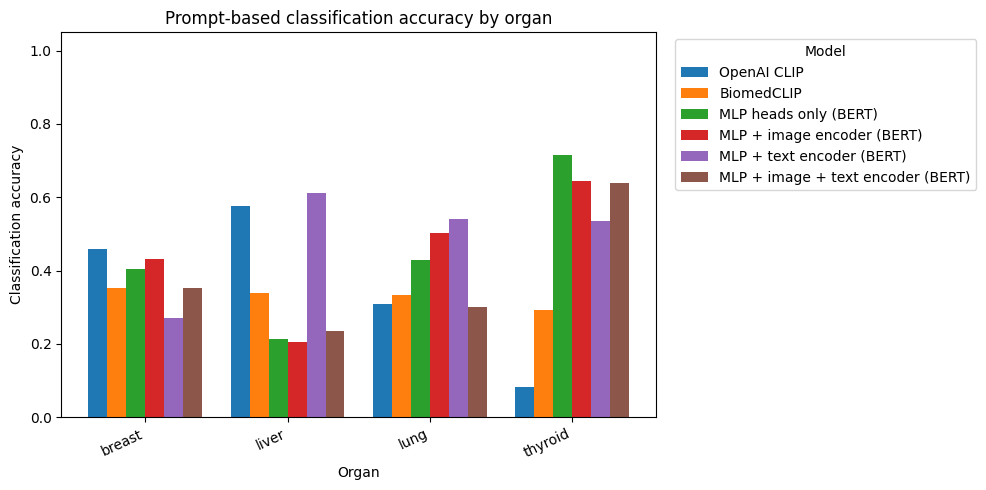

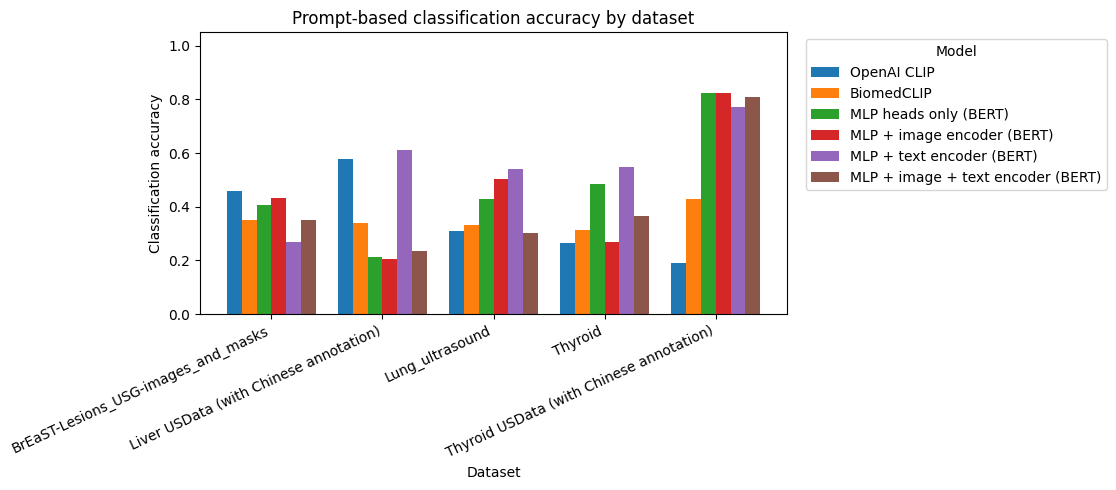

In [41]:

# Grouped bar plots: models clustered within each organ / dataset

# Reuse existing color map if available; otherwise define a fallback.
# if "model_colors" not in globals():
model_colors = {
    "OpenAI CLIP": "#1f77b4",
    "BiomedCLIP": "#ff7f0e",
    "MLP head only (BERT)": "#2ca02c",
    "MLP + image encoder (BERT)": "#d62728",
    "MLP + text encoder (BERT)": "#9467bd",
    "MLP + image + text encoder (BERT)": "#8c564b",
}

def plot_grouped_accuracy_bars(results_df, title, xlabel):
    if len(results_df) == 0:
        print(f"No results available for: {title}")
        return

    models = list(results_df["model"].drop_duplicates())
    groups = list(results_df["group_name"].drop_duplicates())

    # preserve a sensible group ordering using sample count, then name
    group_order_df = (
        results_df[["group_name", "n_samples"]]
        .drop_duplicates()
        .sort_values(["group_name"])
    )
    groups = group_order_df["group_name"].tolist()

    width = 0.8 / max(len(models), 1)
    x = np.arange(len(groups))

    fig_width = max(10, 1.4 * len(groups) + 4)
    fig, ax = plt.subplots(figsize=(fig_width, 5))

    for i, model_name in enumerate(models):
        sub = results_df[results_df["model"] == model_name].copy()
        sub = sub.set_index("group_name").reindex(groups)
        heights = sub["accuracy"].to_numpy(dtype=float)

        ax.bar(
            x + (i - (len(models) - 1) / 2) * width,
            heights,
            width=width,
            label=model_name,
            color=model_colors.get(model_name, "#2ca02c"),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=25, ha="right")
    ax.set_ylabel("Classification accuracy")
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_grouped_accuracy_bars(
    per_organ_classification_results,
    title="Prompt-based classification accuracy by organ",
    xlabel="Organ",
)

plot_grouped_accuracy_bars(
    per_dataset_classification_results,
    title="Prompt-based classification accuracy by dataset",
    xlabel="Dataset",
)


### Save all outputs from the organized notebook

In [40]:
from pathlib import Path
import shutil
from IPython.display import FileLink

final_results_dir = Path("/kaggle/working/final_eval_outputs")
final_results_dir.mkdir(parents=True, exist_ok=True)

def safe_save(obj_name, filename, folder=final_results_dir):
    if obj_name in globals():
        try:
            globals()[obj_name].to_csv(folder / filename, index=False)
            print(f"Saved: {filename}")
        except Exception as e:
            print(f"Failed to save {filename}: {e}")
    else:
        print(f"Skipped (not found): {obj_name}")

# ----------------------------
# Core outputs
# ----------------------------
safe_save("alignment_results", "alignment_results.csv")
safe_save("classification_results", "classification_results.csv")
safe_save("linear_probe_per_organ", "linear_probe_per_organ.csv")
safe_save("linear_probe_aggregate", "linear_probe_aggregate.csv")
safe_save("fewshot_per_organ_raw", "fewshot_per_organ_raw.csv")
safe_save("fewshot_per_organ_summary", "fewshot_per_organ_summary.csv")
safe_save("fewshot_aggregate_raw", "fewshot_aggregate_raw.csv")
safe_save("fewshot_aggregate_summary", "fewshot_aggregate_summary.csv")

# ----------------------------
# Diagnostics
# ----------------------------
safe_save("retrieval_results", "retrieval_results.csv")
safe_save("linear_probe_ci", "linear_probe_bootstrap_ci.csv")
safe_save("best_by_organ", "best_model_by_organ.csv")

# ----------------------------
# Per-organ / dataset outputs
# ----------------------------
per_organ_dir = final_results_dir / "per_organ"
per_organ_dir.mkdir(parents=True, exist_ok=True)

safe_save("organ_label_space", "organ_label_space.csv", per_organ_dir)
safe_save("dataset_label_space", "dataset_label_space.csv", per_organ_dir)
safe_save("per_organ_classification_results", "per_organ_classification_results.csv", per_organ_dir)
safe_save("per_dataset_classification_results", "per_dataset_classification_results.csv", per_organ_dir)

print("\nAll available outputs saved to:", final_results_dir)

# ----------------------------
# Zip everything
# ----------------------------
zip_path = shutil.make_archive("/kaggle/working/final_eval_outputs", "zip", final_results_dir)
print("Created zip:", zip_path)
FileLink(zip_path)

Saved: alignment_results.csv
Saved: classification_results.csv
Saved: linear_probe_per_organ.csv
Saved: linear_probe_aggregate.csv
Saved: fewshot_per_organ_raw.csv
Saved: fewshot_per_organ_summary.csv
Saved: fewshot_aggregate_raw.csv
Saved: fewshot_aggregate_summary.csv
Saved: retrieval_results.csv
Saved: linear_probe_bootstrap_ci.csv
Saved: best_model_by_organ.csv
Saved: organ_label_space.csv
Saved: dataset_label_space.csv
Saved: per_organ_classification_results.csv
Saved: per_dataset_classification_results.csv

All available outputs saved to: /kaggle/working/final_eval_outputs
Created zip: /kaggle/working/final_eval_outputs.zip


/kaggle/working/final_eval_outputs.zip

In [ ]:
import copy
import gc
from collections import defaultdict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

config.update({
    # 8 points on the AUROC curve; adjust if runtime is too long
    "fewshot_e2e_fracs": [0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30],
    "fewshot_e2e_num_seeds": 3,

    # conservative defaults
    "fewshot_e2e_epochs": 8,
    "fewshot_e2e_batch_size": 16,
    "fewshot_e2e_weight_decay": 1e-4,
    "fewshot_e2e_grad_clip": 1.0,

    # per-model-type LR
    "fewshot_e2e_lr": {
        "trained": 1e-5,
        "openai": 5e-6,
        "biomedclip": 5e-6,
    },
})

# If OpenAI CLIP crashes on CUDA in Kaggle, force it to CPU here.
fewshot_device_map = {
    # "OpenAI CLIP": torch.device("cpu") if "OpenAI CLIP" in model_registry else device,
    "OpenAI CLIP": device,
    "BiomedCLIP": device,
}
for model_name in trained_models:
    fewshot_device_map[model_name] = device

ORGAN_DISPLAY = {
    "breast": "breast",
    "lung": "lung",
    "liver": "liver",
    "thyroid": "thyroid",
    "carotid": "carotid artery",
}

def build_label_prompt_for_organ(label, organ):
    organ_text = ORGAN_DISPLAY.get(str(organ).strip().lower(), str(organ).strip().lower())
    label = str(label).strip().lower()
    return f"An ultrasound image of {organ_text} with {label} findings."

# Change config for fast training
config["fewshot_e2e_fracs"] = [0.01, 0.05, 0.10]
config["fewshot_e2e_num_seeds"] = 1
config["fewshot_e2e_epochs"] = 4

In [ ]:
trained_img_transform = transforms.Compose([
    transforms.Resize(config["image_size"]),
    transforms.CenterCrop(config["image_size"]),
    transforms.ToTensor(),
    transforms.Normalize(mean=config["img_mean"], std=config["img_std"]),
])

def load_pil_images(paths):
    return [Image.open(p).convert("RGB") for p in paths]

def sample_fewshot_per_class(df, frac, seed, label_col="label"):
    pieces = []
    for label, group in df.groupby(label_col):
        n = int(np.ceil(len(group) * frac))
        if len(group) >= 2:
            n = max(2, n)
        else:
            n = 1
        n = min(len(group), n)
        pieces.append(group.sample(n=n, random_state=seed))
    out = pd.concat(pieces, axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def multiclass_metrics(y_true, y_pred, y_prob, class_names):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        if len(class_names) == 2:
            pos_class = class_names[1]
            y_true_bin = (np.asarray(y_true) == pos_class).astype(int)
            pos_idx = list(class_names).index(pos_class)
            out["auroc"] = roc_auc_score(y_true_bin, y_prob[:, pos_idx])
        else:
            y_bin = label_binarize(y_true, classes=class_names)
            out["auroc"] = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        out["auroc"] = np.nan

    return out

def summarize_across_organs(per_organ_df):
    if per_organ_df.empty:
        return pd.DataFrame(columns=["average_type", "auroc", "accuracy", "f1_weighted", "n_organs"])

    rows = []
    weights = per_organ_df["n_eval"].to_numpy()

    for avg_name in ["macro", "weighted_by_test_n"]:
        row = {"average_type": avg_name, "n_organs": int(len(per_organ_df))}
        for metric in ["auroc", "accuracy", "f1_weighted"]:
            vals = per_organ_df[metric].to_numpy(dtype=float)
            mask = ~np.isnan(vals)
            if mask.sum() == 0:
                row[metric] = np.nan
            elif avg_name == "macro":
                row[metric] = float(vals[mask].mean())
            else:
                row[metric] = float(np.average(vals[mask], weights=weights[mask]))
        rows.append(row)

    return pd.DataFrame(rows)

def iterate_minibatches(df, batch_size, seed):
    idx = np.arange(len(df))
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    for start in range(0, len(idx), batch_size):
        yield df.iloc[idx[start:start + batch_size]].reset_index(drop=True)

In [ ]:
def clone_model_for_fewshot(model_name, spec, target_device):
    model = copy.deepcopy(spec["model"])
    model = model.to(target_device)
    model.train()
    return model

def get_trainable_scale(kind, model):
    if kind == "trained":
        # training code used sim / temperature
        scale = 1.0 / model.log_temperature.exp()
    else:
        scale = model.logit_scale.exp()
    return torch.clamp(scale, max=100.0)

def encode_text_prompts(kind, model, prompt_texts, target_device):
    if kind == "trained":
        ids, mask = tokenize_texts(
            list(prompt_texts),
            tokenizer,
            max_length=config["max_seq_len"],
            device=target_device,
        )
        text_embs = model.encode_text(ids, mask)
        return text_embs

    elif kind == "openai":
        text_inputs = openai_clip_processor(
            text=list(prompt_texts),
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(target_device)

        text_outputs = model.text_model(
            input_ids=text_inputs["input_ids"],
            attention_mask=text_inputs["attention_mask"],
        )
        text_embs = model.text_projection(text_outputs.pooler_output)
        text_embs = F.normalize(text_embs, dim=-1)
        return text_embs

    elif kind == "biomedclip":
        text_tokens = biomedclip_tokenizer(list(prompt_texts), context_length=256).to(target_device)
        text_embs = model.encode_text(text_tokens)
        text_embs = F.normalize(text_embs, dim=-1)
        return text_embs

    else:
        raise ValueError(f"Unknown kind: {kind}")

def encode_image_batch(kind, model, image_paths, target_device):
    pil_images = load_pil_images(image_paths)

    if kind == "trained":
        images = torch.stack([trained_img_transform(img) for img in pil_images]).to(target_device)
        img_embs = model.encode_image(images)
        return img_embs

    elif kind == "openai":
        img_inputs = openai_clip_processor(
            images=pil_images,
            return_tensors="pt",
        ).to(target_device)

        vision_outputs = model.vision_model(pixel_values=img_inputs["pixel_values"])
        img_embs = model.visual_projection(vision_outputs.pooler_output)
        img_embs = F.normalize(img_embs, dim=-1)
        return img_embs

    elif kind == "biomedclip":
        images = torch.stack([biomedclip_preprocess(img) for img in pil_images]).to(target_device)
        img_embs = model.encode_image(images)
        img_embs = F.normalize(img_embs, dim=-1)
        return img_embs

    else:
        raise ValueError(f"Unknown kind: {kind}")

In [ ]:
def evaluate_prompt_classifier(kind, model, df, class_names, organ, target_device, batch_size=32):
    model.eval()

    prompt_texts = [build_label_prompt_for_organ(c, organ) for c in class_names]
    with torch.no_grad():
        text_embs = encode_text_prompts(kind, model, prompt_texts, target_device)
        scale = get_trainable_scale(kind, model)

    y_true, y_pred = [], []
    all_probs = []

    for start in range(0, len(df), batch_size):
        batch_df = df.iloc[start:start + batch_size].reset_index(drop=True)
        image_paths = batch_df["image_path"].tolist()

        with torch.no_grad():
            img_embs = encode_image_batch(kind, model, image_paths, target_device)
            logits = scale * (img_embs @ text_embs.T)
            probs = torch.softmax(logits, dim=1).cpu().numpy()

        pred_idx = probs.argmax(axis=1)
        pred_labels = [class_names[i] for i in pred_idx]

        y_true.extend(batch_df["label"].astype(str).str.lower().tolist())
        y_pred.extend(pred_labels)
        all_probs.append(probs)

    y_prob = np.concatenate(all_probs, axis=0)
    metrics = multiclass_metrics(y_true, y_pred, y_prob, class_names)
    metrics["n_eval"] = int(len(y_true))
    return metrics, y_true, y_pred, y_prob

def train_prompt_classifier_for_one_organ(model_name, spec, support_df, val_df, organ, class_names, seed, target_device):
    kind = spec["kind"]

    model = clone_model_for_fewshot(model_name, spec, target_device)
    lr = config["fewshot_e2e_lr"][kind]

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=config["fewshot_e2e_weight_decay"],
    )

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -np.inf
    history = []

    for epoch in range(config["fewshot_e2e_epochs"]):
        model.train()
        epoch_losses = []

        for batch_df in iterate_minibatches(support_df, config["fewshot_e2e_batch_size"], seed + epoch):
            image_paths = batch_df["image_path"].tolist()
            labels = batch_df["label"].astype(str).str.lower().tolist()

            label_to_idx = {c: i for i, c in enumerate(class_names)}
            targets = torch.tensor([label_to_idx[y] for y in labels], dtype=torch.long, device=target_device)

            prompt_texts = [build_label_prompt_for_organ(c, organ) for c in class_names]

            img_embs = encode_image_batch(kind, model, image_paths, target_device)
            text_embs = encode_text_prompts(kind, model, prompt_texts, target_device)
            scale = get_trainable_scale(kind, model)

            logits = scale * (img_embs @ text_embs.T)
            loss = F.cross_entropy(logits, targets)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config["fewshot_e2e_grad_clip"])
            optimizer.step()

            epoch_losses.append(loss.item())

        # validation selection
        val_metrics, _, _, _ = evaluate_prompt_classifier(
            kind=kind,
            model=model,
            df=val_df,
            class_names=class_names,
            organ=organ,
            target_device=target_device,
            batch_size=config["fewshot_e2e_batch_size"],
        )

        mean_loss = float(np.mean(epoch_losses)) if epoch_losses else np.nan
        history.append({
            "epoch": epoch + 1,
            "train_loss": mean_loss,
            "val_auroc": val_metrics["auroc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1_weighted": val_metrics["f1_weighted"],
        })

        if val_metrics["f1_weighted"] > best_val_f1:
            best_val_f1 = val_metrics["f1_weighted"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    return model, pd.DataFrame(history), best_val_f1

def run_e2e_fewshot_for_one_organ(model_name, spec, train_meta, val_meta, test_meta, organ, frac, seed, target_device):
    tr = train_meta[train_meta["organ"] == organ].copy()
    va = val_meta[val_meta["organ"] == organ].copy()
    te = test_meta[test_meta["organ"] == organ].copy()

    train_counts = tr["label"].value_counts()
    keep_classes = train_counts[train_counts >= 2].index.tolist()

    tr = tr[tr["label"].isin(keep_classes)].copy()
    va = va[va["label"].isin(keep_classes)].copy()
    te = te[te["label"].isin(keep_classes)].copy()

    if tr["label"].nunique() < 2 or len(te) == 0:
        return None, None

    support_df = sample_fewshot_per_class(tr, frac=frac, seed=seed, label_col="label")
    class_names = sorted(support_df["label"].astype(str).str.lower().unique().tolist())

    va = va[va["label"].isin(class_names)].copy()
    te = te[te["label"].isin(class_names)].copy()

    if len(va) == 0 or len(te) == 0 or len(class_names) < 2:
        return None, None

    adapted_model, train_hist_df, best_val_f1 = train_prompt_classifier_for_one_organ(
        model_name=model_name,
        spec=spec,
        support_df=support_df,
        val_df=va,
        organ=organ,
        class_names=class_names,
        seed=seed,
        target_device=target_device,
    )

    test_metrics, y_true, y_pred, y_prob = evaluate_prompt_classifier(
        kind=spec["kind"],
        model=adapted_model,
        df=te,
        class_names=class_names,
        organ=organ,
        target_device=fewshot_device_map[model_name],
        batch_size=config["fewshot_e2e_batch_size"],
    )

    row = {
        "model": model_name,
        "setting": "fewshot_e2e_full_clip",
        "fewshot_frac": frac,
        "seed": seed,
        "organ": organ,
        "n_train_support": int(len(support_df)),
        "n_val": int(len(va)),
        "n_test": int(len(te)),
        "n_classes": int(len(class_names)),
        "best_val_f1_weighted": float(best_val_f1),
        **test_metrics,
    }

    # free memory aggressively
    del adapted_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return row, train_hist_df

In [ ]:
import gc
import torch

del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
e2e_fewshot_rows = []
e2e_fewshot_histories = []

train_meta = labeled_train_df.copy().reset_index(drop=True)
val_meta   = labeled_val_df.copy().reset_index(drop=True)
test_meta  = labeled_test_df.copy().reset_index(drop=True)

organs = sorted(set(train_meta["organ"]) & set(val_meta["organ"]) & set(test_meta["organ"]))

for model_name, spec in model_registry.items():
    print(f"\n=== End-to-end few-shot adaptation: {model_name} ===")
    print("device:", fewshot_device_map[model_name])

    for frac in config["fewshot_e2e_fracs"]:
        print(f"  fraction = {frac:.3f}")

        for rep in range(config["fewshot_e2e_num_seeds"]):
            seed = config["random_seed"] + rep

            for organ in organs:
                print(f"    seed={seed} organ={organ}")

                row, hist_df = run_e2e_fewshot_for_one_organ(
                    model_name=model_name,
                    spec=spec,
                    train_meta=train_meta,
                    val_meta=val_meta,
                    test_meta=test_meta,
                    organ=organ,
                    frac=frac,
                    seed=seed,
                    target_device="cuda:1",
                )

                if row is not None:
                    e2e_fewshot_rows.append(row)
                    hist_df["model"] = model_name
                    hist_df["fewshot_frac"] = frac
                    hist_df["seed"] = seed
                    hist_df["organ"] = organ
                    e2e_fewshot_histories.append(hist_df)

e2e_fewshot_per_organ_raw = pd.DataFrame(e2e_fewshot_rows)
e2e_fewshot_training_history = (
    pd.concat(e2e_fewshot_histories, ignore_index=True)
    if len(e2e_fewshot_histories) > 0
    else pd.DataFrame()
)

print("Done.")
print("rows:", len(e2e_fewshot_per_organ_raw))
e2e_fewshot_per_organ_raw.head()

In [ ]:
e2e_fewshot_aggregate_rows = []

for (model_name, frac, seed), df_seed in e2e_fewshot_per_organ_raw.groupby(["model", "fewshot_frac", "seed"]):
    agg = summarize_across_organs(df_seed)
    agg["model"] = model_name
    agg["setting"] = "fewshot_e2e_full_clip"
    agg["fewshot_frac"] = frac
    agg["seed"] = seed
    e2e_fewshot_aggregate_rows.append(agg)

e2e_fewshot_aggregate_raw = pd.concat(e2e_fewshot_aggregate_rows, ignore_index=True)

e2e_fewshot_aggregate_summary = (
    e2e_fewshot_aggregate_raw
    .groupby(["model", "setting", "fewshot_frac", "average_type"], as_index=False)
    .agg(
        auroc_mean=("auroc", "mean"),
        auroc_std=("auroc", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_weighted_mean=("f1_weighted", "mean"),
        f1_weighted_std=("f1_weighted", "std"),
        n_organs_mean=("n_organs", "mean"),
    )
)

e2e_fewshot_per_organ_summary = (
    e2e_fewshot_per_organ_raw
    .groupby(["model", "setting", "fewshot_frac", "organ"], as_index=False)
    .agg(
        auroc_mean=("auroc", "mean"),
        auroc_std=("auroc", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_weighted_mean=("f1_weighted", "mean"),
        f1_weighted_std=("f1_weighted", "std"),
        n_test_mean=("n_test", "mean"),
    )
)

display(
    e2e_fewshot_aggregate_summary.sort_values(
        ["average_type", "fewshot_frac", "auroc_mean"],
        ascending=[True, True, False]
    )
)

In [ ]:
# AUROC curve with more points
plot_df = e2e_fewshot_aggregate_summary[
    e2e_fewshot_aggregate_summary["average_type"] == "weighted_by_test_n"
].copy()

fig, ax = plt.subplots(figsize=(10, 5))

for model_name in plot_df["model"].unique():
    sub = plot_df[plot_df["model"] == model_name].sort_values("fewshot_frac")
    x = sub["fewshot_frac"].to_numpy() * 100
    y = sub["auroc_mean"].to_numpy()
    yerr = sub["auroc_std"].fillna(0).to_numpy()

    ax.plot(x, y, marker="o", label=model_name)
    ax.fill_between(x, y - yerr, y + yerr, alpha=0.15)

ax.set_xlabel("Labeled support fraction (%)")
ax.set_ylabel("Weighted aggregate AUROC")
ax.set_title("End-to-end few-shot adaptation of full CLIP models")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
e2e_results_dir = Path("/kaggle/working/final_eval_outputs/e2e_fewshot_eval")
e2e_results_dir.mkdir(parents=True, exist_ok=True)

e2e_fewshot_per_organ_raw.to_csv(e2e_results_dir / "e2e_fewshot_per_organ_raw.csv", index=False)
e2e_fewshot_per_organ_summary.to_csv(e2e_results_dir / "e2e_fewshot_per_organ_summary.csv", index=False)
e2e_fewshot_aggregate_raw.to_csv(e2e_results_dir / "e2e_fewshot_aggregate_raw.csv", index=False)
e2e_fewshot_aggregate_summary.to_csv(e2e_results_dir / "e2e_fewshot_aggregate_summary.csv", index=False)

if len(e2e_fewshot_training_history) > 0:
    e2e_fewshot_training_history.to_csv(e2e_results_dir / "e2e_fewshot_training_history.csv", index=False)

print("Saved to:", e2e_results_dir)

import shutil
from IPython.display import FileLink

zip_path = shutil.make_archive("/kaggle/working/final_eval_outputs", "zip", final_results_dir)
print("Created zip:", zip_path)
FileLink(zip_path)